# 1) Introducción al proyecto

Exploraremos los "insights" sobre como se han comportado las ventas de la empresa reckitt, el análisis es importante
porqué así podemos conocer más a fondo el rendimiento de la empresa y con esto será más fácil conocer las áreas de mejora

# 2) Limpieza y transformación de datos

In [1]:
# Importamos las librerías que vamos a usar durante  el proceso

import pandas as pd 
import numpy as np 
import warnings
import matplotlib.pyplot as plt
import os 

warnings.filterwarnings('ignore')

In [2]:
# Ruta de el directorio donde tenemos nuestro material
os.chdir('C:/Users/danie/Documents/EBAC/Github/cientifico-d-datos/entrega-final/data')    

In [3]:
# Cargamos los difetentes archivos con los que vamos a trabajar con las siguientes instrucciones:
# Guardaremos los DataFrames con '_original' así cuando escalemos nuestros 'DF' tendremos la versión original y la 'escalada'
sales_df_original = pd.read_csv('FACT_SALES (1).csv') 
product_df_original = pd.read_excel('DIM_PRODUCT (1).xlsx')
segment_df_original= pd.read_excel('DIM_SEGMENT (1).xlsx')
calendar_df_original = pd.read_excel ('DIM_CALENDAR (2).xlsx')
category_df_original= pd.read_csv ('DIM_CATEGORY (2).csv')

In [4]:
# Mostramos la primer fila de nuestro encabezado 'head' para verificar que se cargó correctamente
sales_df_original.head(1)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.0,TOTAL AUTOS AREA 5


In [5]:
# Mostramos la primer fila de nuestro encabezado 'head' para verificar que se cargó correctamente
product_df_original.head(1)

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [6]:
# Mostramos la primer fila de nuestro encabezado 'head' para verificar que se cargó correctamente
segment_df_original.head(1)

,CATEGORY,ATTR1,ATTR2,ATTR3,FORMAT,SEGMENT
0,1,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH


In [7]:
# Mostramos la primer fila de nuestro encabezado 'head' para verificar que se cargó correctamente
calendar_df_original.head(1)

,WEEK,YEAR,MONTH,WEEK_NUMBER,DATE
0,01-21,2021,1,1,2021-01-10


In [8]:
# Mostramos la primer fila de nuestro encabezado 'head' para verificar que se cargó correctamente
category_df_original.head(1)

,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT\r\n


### Revisaremos si existen valores nulos y duplicados en nuestros Dataframes

In [9]:
# Suma de valores nulos en nuestro DF
print(sales_df_original.isnull().sum())

WEEK                           0
ITEM_CODE                      0
TOTAL_UNIT_SALES               0
TOTAL_VALUE_SALES              0
TOTAL_UNIT_AVG_WEEKLY_SALES    0
REGION                         0
dtype: int64


In [10]:
# Suma de valores duplicados en nuestro DF
print(sales_df_original.duplicated().sum()) 

0


In [11]:
# Suma de valores nulos en nuestro DF
print(product_df_original.isnull().sum())

MANUFACTURER        0
BRAND               0
ITEM                2
ITEM_DESCRIPTION    0
CATEGORY            0
FORMAT              0
ATTR1               6
ATTR2               0
ATTR3               6
dtype: int64


In [12]:
# Suma de valores duplicados en nuestro DF
print(product_df_original.duplicated().sum()) 

0


In [13]:
# Suma de valores nulos en nuestro DF
print(segment_df_original.isnull().sum())

CATEGORY    0
ATTR1       0
ATTR2       0
ATTR3       1
FORMAT      0
SEGMENT     0
dtype: int64


In [14]:
# Suma de valores duplicados en nuestro DF
print(segment_df_original.duplicated().sum()) 

0


In [15]:
# Suma de valores nulos en nuestro DF
print(calendar_df_original.isnull().sum())

WEEK           0
YEAR           0
MONTH          0
WEEK_NUMBER    0
DATE           0
dtype: int64


In [16]:
# Suma de valores duplicados en nuestro DF
print(calendar_df_original.duplicated().sum()) 

0


In [17]:
# Suma de valores nulos en nuestro DF
print(category_df_original.isnull().sum())

ID_CATEGORY    0
CATEGORY       0
dtype: int64


In [18]:
# Suma de valores duplicados en nuestro DF
print(category_df_original.duplicated().sum()) 

0


### No encontramos valores duplicados en nuestros datos

In [19]:
# Cambiamos los valores nulos por 'NO DEFINIDO'
product_df_original.fillna('NO DEFINIDO', inplace = True)

In [20]:
# Cambiamos los valores nulos por 'NO DEFINIDO'
segment_df_original.fillna('NO DEFINIDO', inplace = True)

### Normalizar Datos

In [21]:
# Escalaremos nuestro DataFrame y le pondremos '_scaled' para identificarlo mejor'
# Para esto creamos una copia del original
sales_df_scaled = sales_df_original.copy()

In [22]:
# Importamos StandardSaler
from sklearn.preprocessing import StandardScaler

# Asignamos nuestro StandardScaler a una variable 
scaler = StandardScaler()

# Creamos una lista con las columnas que vamos a escalar y la guaramos en una variable 'sale_cols'
scale_cols = ['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES']

# Aplicarmos la escala, las columas de la lista 'scale_cols'  
sales_df_scaled[scale_cols] = scaler.fit_transform(sales_df_scaled[scale_cols])           

In [23]:
# Ahora tenemos una versión de nuestro 'sales_df' con las columnas númericas escaladas
sales_df_scaled.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,-0.221103,-0.258040,-0.401761,TOTAL AUTOS AREA 5
1,34-22,7501058715883,-0.187921,0.074251,-0.317169,TOTAL AUTOS AREA 5
2,34-22,7702626213774,-0.125559,-0.062988,-0.217611,TOTAL AUTOS AREA 5


In [24]:
# Nuestro original está intacto
sales_df_original.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5


In [25]:
# Cambiamos nuestra fecha a 'string' de Python con la instrucción '.astype'
sales_df_original['WEEK'] = sales_df_original['WEEK'].astype('string')

In [26]:
# Vamos a dividir nuestro 'WEEK' en 'WEEK' y 'YEAR'. Usaremos '.str.split'
# Esto con la intención de tener la semana y el año independientes
sales_df_original[['WEEK', 'YEAR']] =  sales_df_original['WEEK'].str.split('-', expand = True)

In [27]:
# Verificamos como ahora son columnas independientes
sales_df_original.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR
0,34,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,22
1,34,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,22
2,34,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,22


In [28]:
# Vamos agregar '20' a nuestro 'YEAR' , formato 'YYYY'
sales_df_original['YEAR'] = '20' + sales_df_original['YEAR'] 

In [29]:
# El cambio se hizo correcatamente
sales_df_original.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR
0,34,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022
1,34,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,2022
2,34,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,2022


In [30]:
# Revisamos que tipo de dato es nuestra columna
sales_df_original['WEEK'] .dtypes

string[python]

In [31]:
# Revisamos que tipo de dato es nuestra columna
sales_df_original['YEAR'] .dtypes

string[python]

In [32]:
# Verificamos que no existan nulos
print(sales_df_original['WEEK'].isnull().sum()) 

0


In [33]:
# Verificamos que no existan nulos
print(sales_df_original['YEAR'].isnull().sum()) 

0


In [34]:
# Vamos a crear una nueva columna que se llame 'WEEK_DATE'. La fecha de la semana
# Este proceso lo hacemos porque 'WEEK_DATE' Tendrá un formato 'datetime' y esto nos ayudar cuando querámos hacer nuestra serie de tiempor ARIMA 

sales_df_original['WEEK_DATE'] = pd.to_datetime( # Creamos la columna y el contenido lo cambiamos datetime
    sales_df_original['WEEK'].astype(str) + '-' + sales_df_original['YEAR'].astype(str) + '-1', # Al final concatenamos '-1' que corresponde a lunes
    format = '%W-%Y-%w' # Le indicamos el formato, debe coicidir con el del arriba. W = Week, Y = Year, w = day of de week  
)

In [35]:
# El cambio se hizo correctamente
sales_df_original.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE
0,34,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022,2022-08-22
1,34,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,2022,2022-08-22
2,34,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,2022,2022-08-22


### Vamos a unir los dateframes sales_df y product_df para tener uno más completo

In [36]:
# Visualizamos df_product_original para poder ver en donde vamos a hacer la unión
sales_df_original.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE
0,34,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022,2022-08-22
1,34,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,2022,2022-08-22
2,34,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,2022,2022-08-22


In [37]:
# Visualizamos df_product_original para poder ver en donde vamos a hacer la unión
product_df_original.head(3)

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [38]:
# Comparten la cadena 'ITEM_CODE' pero tienen diferentes nombre, cambiamos el nombre de la 'col' para que coincidan 
product_df_original.rename(columns = {'ITEM': 'ITEM_CODE'}, inplace = True)

In [39]:
# El cambio se hizo correctamente
product_df_original.head(3)

,MANUFACTURER,BRAND,ITEM_CODE,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [40]:
# Hacemos un merge de los DataFrames
sales_product_df_original = pd.merge(sales_df_original, product_df_original, on = 'ITEM_CODE', how = 'right')

In [41]:
# El 'merge' se hizo correctamente
sales_product_df_original.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,45,0000075000592,0.034,0.142,8.5,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-07,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,48,0000075000592,0.002,0.009,1.0,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-28,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,03,0000075000592,0.432,1.956,14.4,TOTAL AUTOS SCANNING MEXICO,2022,2022-01-17,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [42]:
# Creamos una copia para ahora escalar las columnas númericas (las mismas de antes) de nuesto nuevo sales_product_scaled_df
sales_product_df_scaled = sales_product_df_original.copy() 

In [43]:
# Visualizamos
sales_product_df_scaled.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,45,0000075000592,0.034,0.142,8.5,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-07,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,48,0000075000592,0.002,0.009,1.0,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-28,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,03,0000075000592,0.432,1.956,14.4,TOTAL AUTOS SCANNING MEXICO,2022,2022-01-17,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [44]:
# Está 'escalado' vamos a invertir el proceso

sales_product_df_scaled[scale_cols] = scaler.fit_transform(sales_product_df_scaled[scale_cols])

In [45]:
# El cambio se hizo correctameente
sales_product_df_scaled.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,45,0000075000592,-0.219171,-0.258032,-0.070636,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-07,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,48,0000075000592,-0.221379,-0.258411,-0.401761,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-28,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,03,0000075000592,-0.191715,-0.252852,0.189849,TOTAL AUTOS SCANNING MEXICO,2022,2022-01-17,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


# 3) Análisis Exploratorio de Datos (EDA) y Visualizaciones

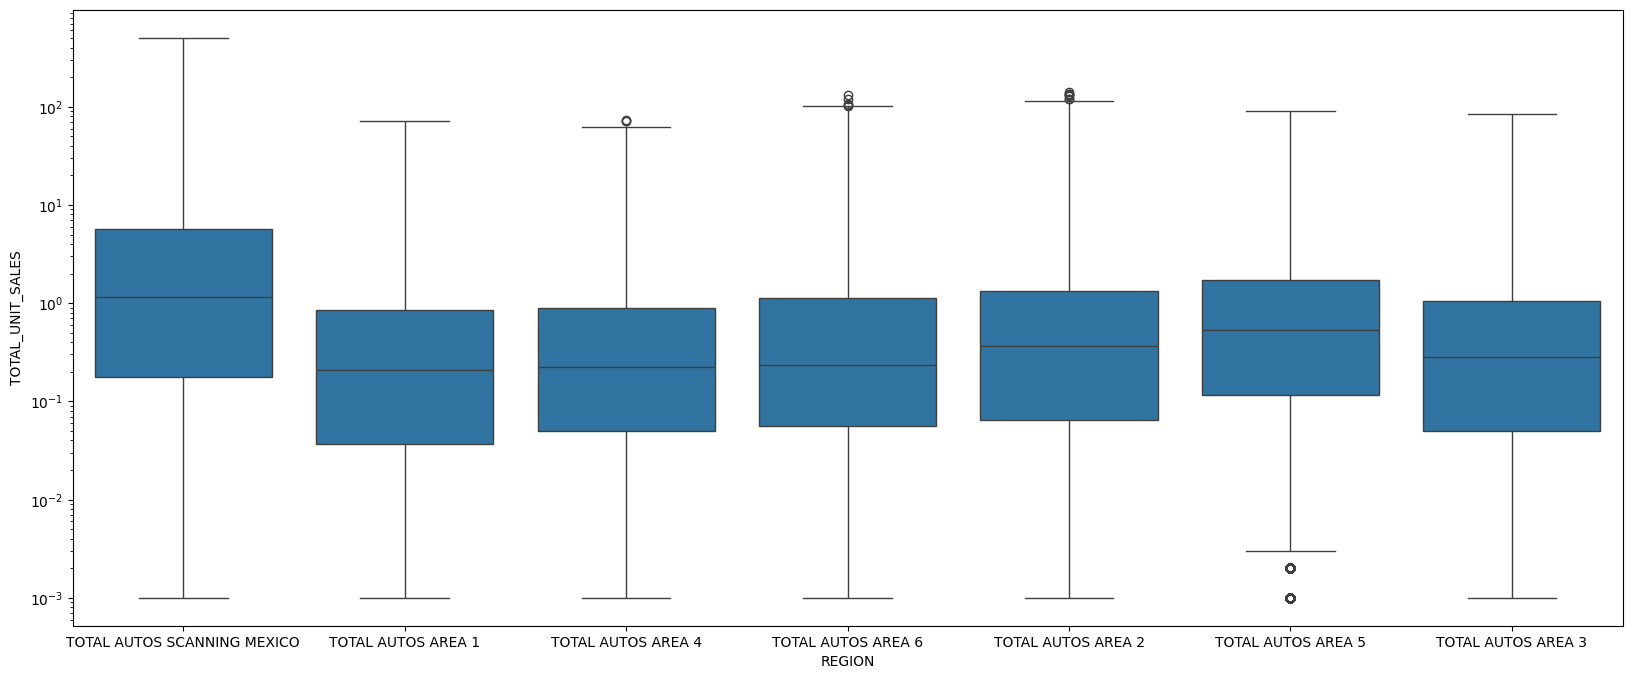

In [46]:
import seaborn as sns

plt.figure(figsize = (20,8))
sns.boxplot(data = sales_product_df_original, x = 'REGION' , y = 'TOTAL_UNIT_SALES', log_scale = True)
plt.savefig("Boxplot-total-units-per-Region-e-final")

In [47]:
# Agrupamos por semana 'TOTAL_UNIT SALES'
# Ahora tenemos un nuevo DataFrame
weekly_sales_df_original = sales_df_original.groupby('WEEK')['TOTAL_VALUE_SALES'].sum().reset_index()

In [48]:
# Visualizamos nuestro DataFrame
weekly_sales_df_original.head(3)

,WEEK,TOTAL_VALUE_SALES
0,01,317847.966
1,02,302652.873
2,03,261125.548


# plot - pandas

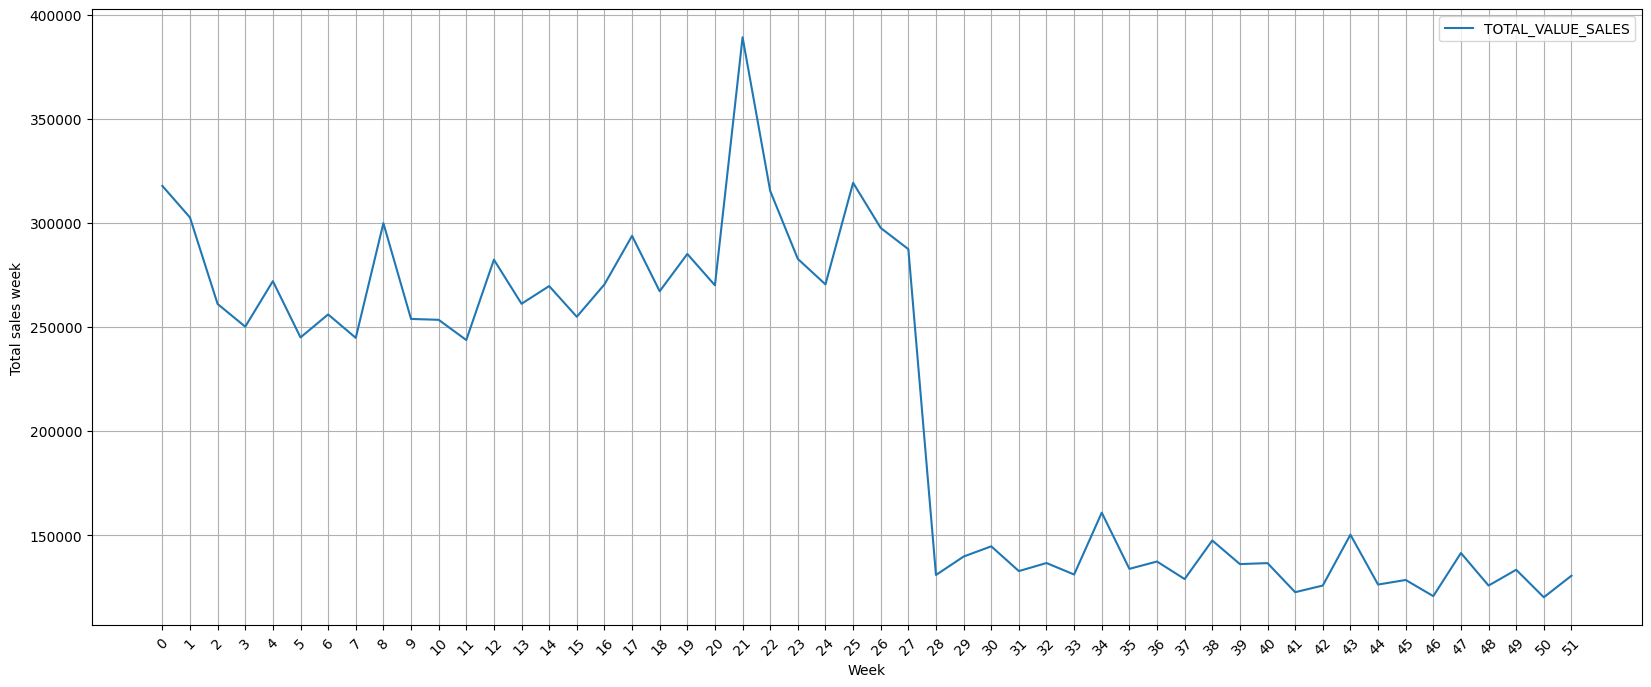

In [49]:
import pandas as pd 
import matplotlib.pyplot as plt

weekly_sales_df_original.plot(kind = 'line',
                              figsize = (20,8)
                             )

# Personalización 

plt.xlabel('Week') # Nuestra etiqueta del eje X
plt.ylabel('Total sales week') # Nuestra etiqueta del eje Y
plt.grid(True)

# Ticks para mofificar los ticks
plt.xticks(ticks = weekly_sales_df_original.index, # Muestros 'ticks' son lo mismo que nuestro indice
           rotation = 45  # Rota nuestros 'ticks' 45 grados 
)
plt.savefig ('plot-weekly-value-sales-e-final.png')
plt.show()

### Podemos observar que hay una caida en las ventas totales a partir de la semana 29
de ahí ha tenido subirdas y bajadas pequeñas pero se mantiene por debajo de los 20,000

### barplot - seaborn

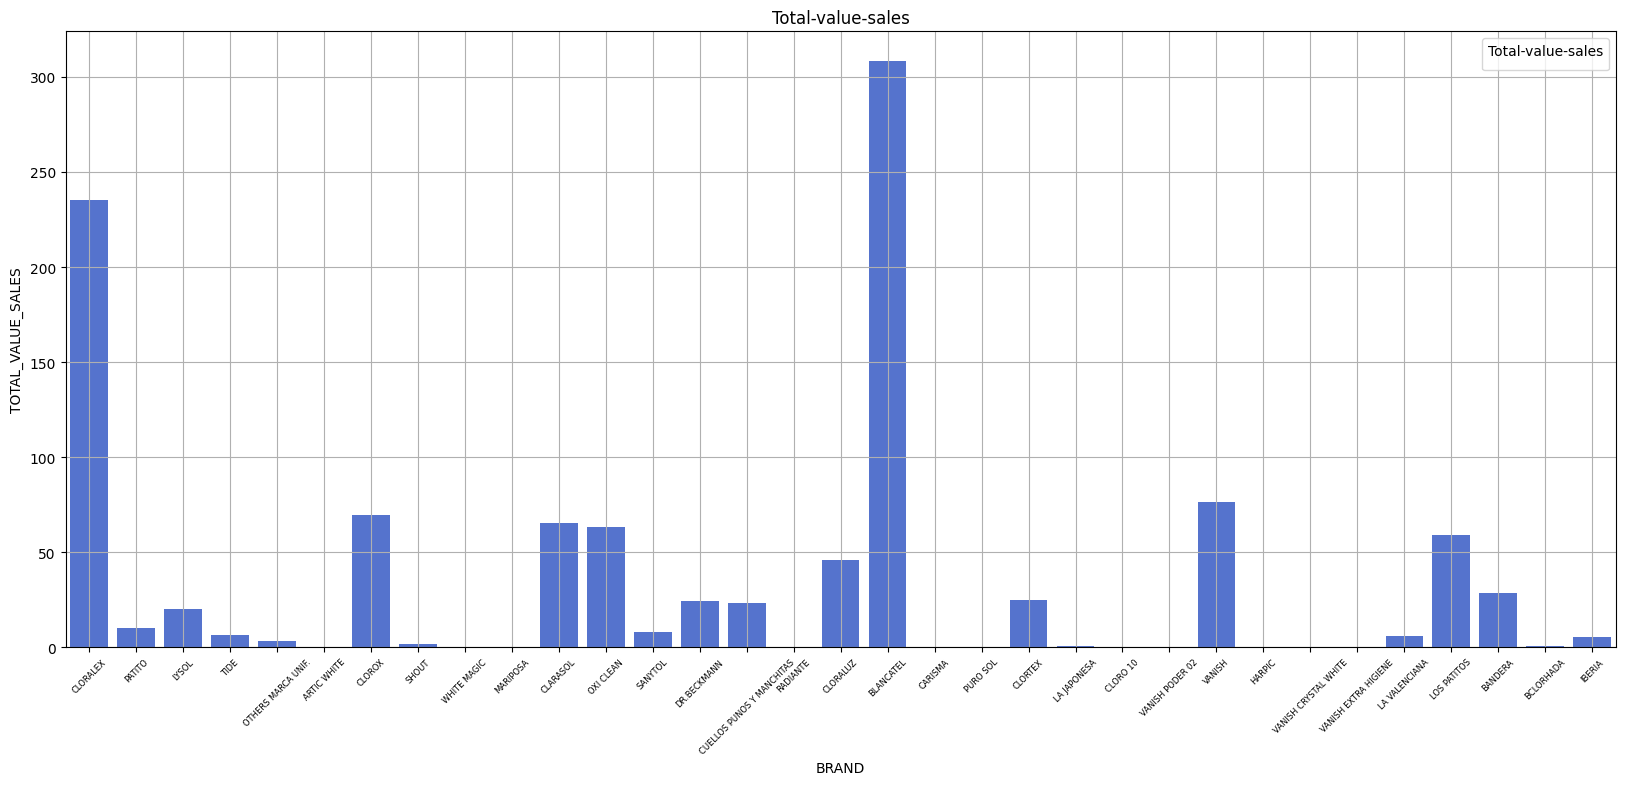

In [50]:
plt.figure(figsize = (20,8))
sns.barplot(data = sales_product_df_original,
            x = 'BRAND', y ='TOTAL_VALUE_SALES',
            ci = None, # Para que no muestre el intervalo de confianza
            color = 'royalblue')

# Personalización
plt.xticks(rotation = 45,
           fontsize = 6)
plt.legend(title = "Total-value-sales")
plt.title("Total-value-sales")
plt.grid(True)

plt.savefig('barplot-total-brand-sales.entrega-final.png') 
plt.show()

### Blancatel y Cloralex son las marcas que mas se venden mientras que marcas como Cloro 10, Shout entre otras no han vendido nada

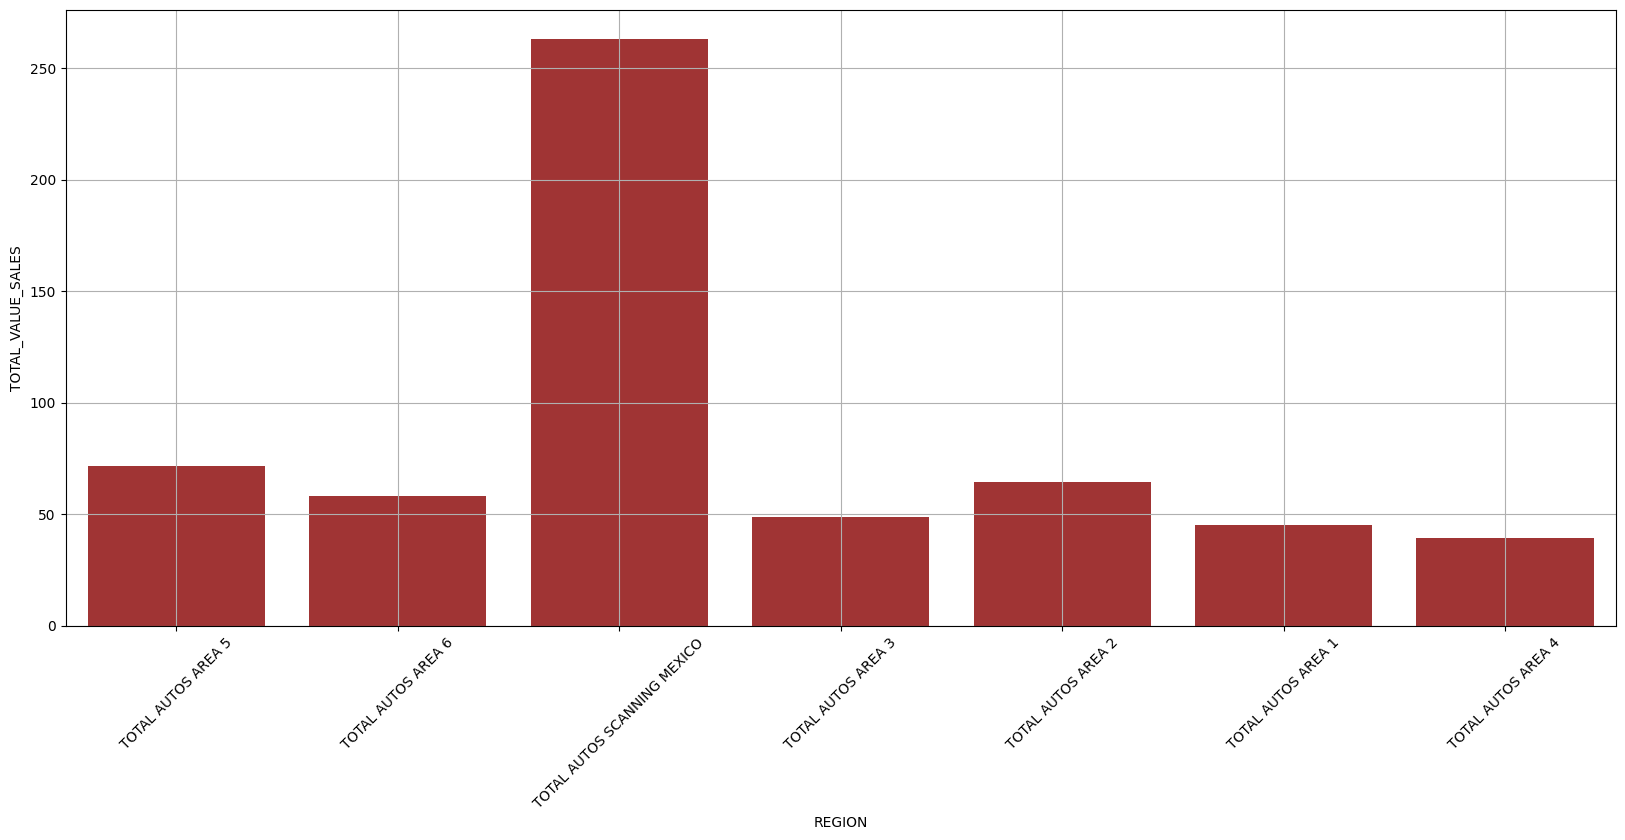

In [51]:
plt.figure(figsize = (20,8))
sns.barplot(data = sales_df_original,
            x = 'REGION', y ='TOTAL_VALUE_SALES',
            ci = None, # Para que no muestre el intervalo de confianza
            color = 'firebrick')

# Personalización
plt.xticks(rotation = 45)
plt.grid(True)

plt.savefig('barplot-total-value-region-e-final.png')  
plt.show()

### La región que lider en ventas es: 'Total Autos Scanning México'

### lineplot-seaborn

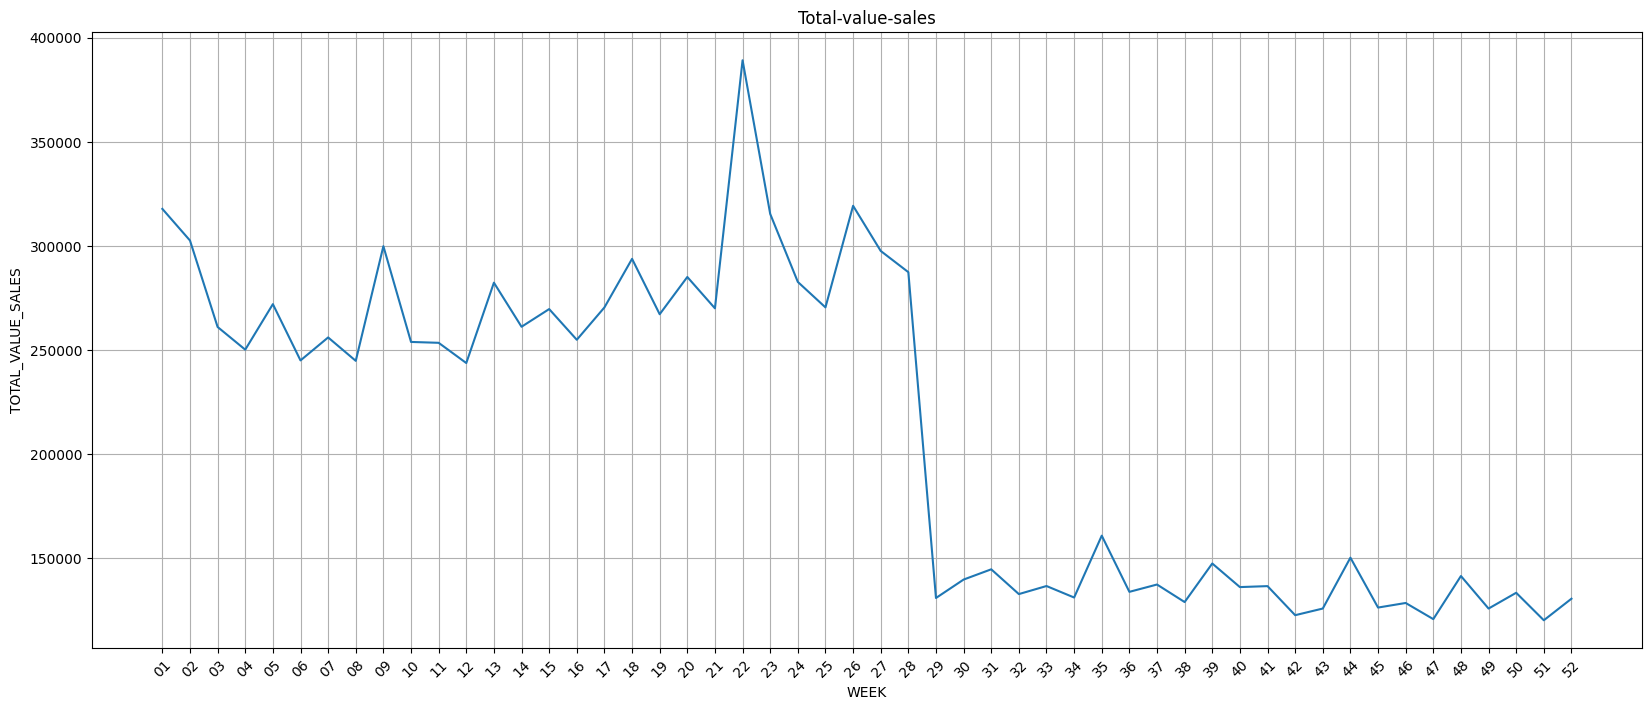

In [52]:
plt.figure(figsize = (20,8))

sns.lineplot(data = weekly_sales_df_original,
             x = 'WEEK',y = 'TOTAL_VALUE_SALES',
             ci = None) # Para que no muestre el intervalo de confianza

# Personalización
plt.title('Total-value-sales')
plt.xticks(ticks = weekly_sales_df_original.index,
           rotation = 45,
           fontsize = 10)

plt.grid(True)

plt.savefig('lineplot-sns-total-value-sales.png')  
plt.show()

### scatter - matplotlib

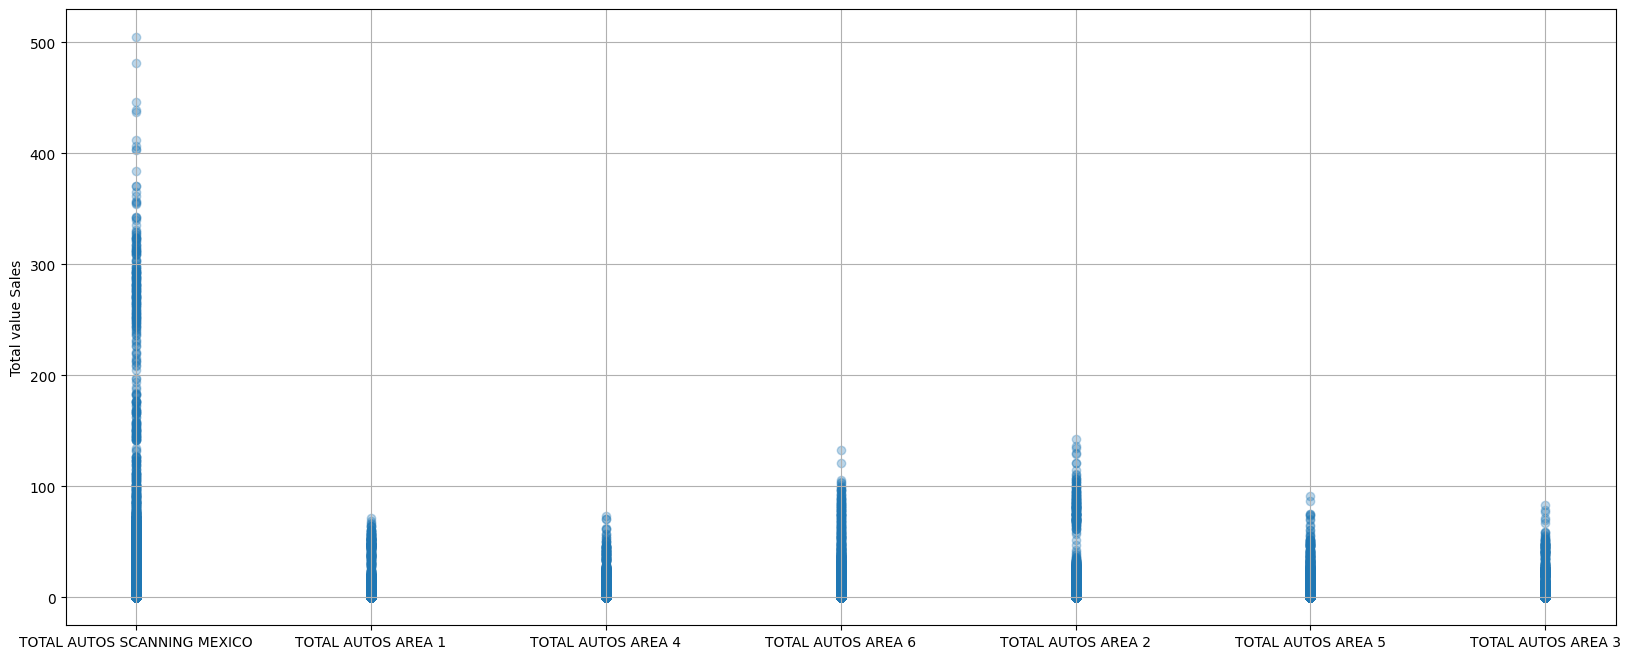

In [53]:
fig, ax = plt.subplots(figsize = (20,8))

plt.scatter(sales_product_df_original['REGION'].astype(str) ,sales_product_df_original['TOTAL_UNIT_SALES'],alpha = 0.3)
plt.ylabel('Total value Sales')

# Personalización 
plt.grid(True)

plt.savefig('scatterplot-total-value-sales-e-final.png')  
plt.show()

In [54]:
### scatterplot -seaborn

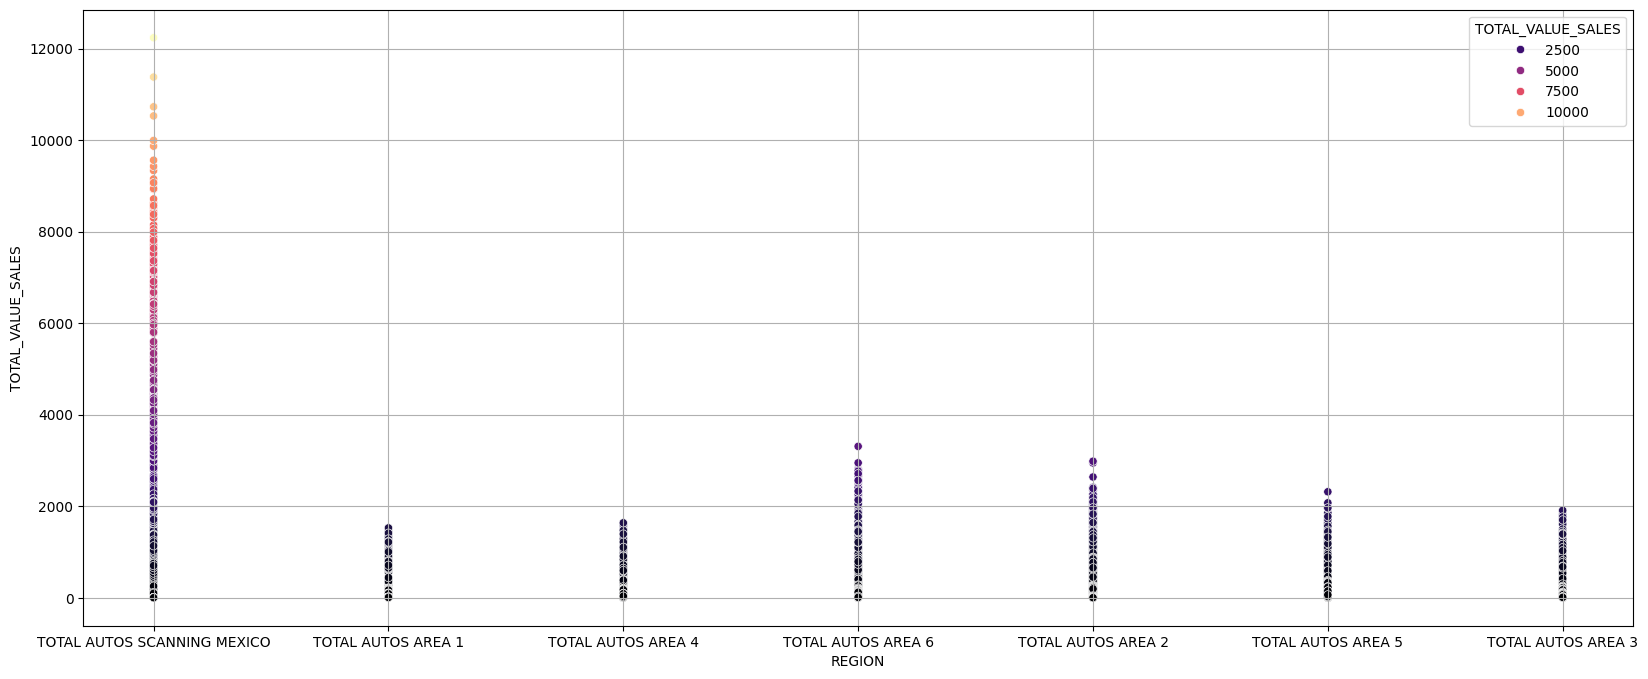

In [55]:
plt.figure(figsize = (20,8))
sns.scatterplot(data = sales_product_df_original,
                x = 'REGION', y = 'TOTAL_VALUE_SALES',
                hue = 'TOTAL_VALUE_SALES',
                palette = 'magma' )

# Personalización
plt.grid(True)

plt.savefig('scatterplot-sns-region-total-value-sales.png')  
plt.show()

### DataFrame año 2022

In [56]:
# Creamos una copia de nuestro Dataframe
sales_product_2022_df_original = sales_product_df_original.copy()

In [57]:
sales_product_2022_df_original.head(1)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,45,0000075000592,0.034,0.142,8.5,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-07,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [58]:
# Creamos un DataFrame con solo las ventas del 2022
sales_product_2022_df_original = sales_product_2022_df_original[sales_product_2022_df_original['YEAR'] == '2022']

In [59]:
sales_product_2022_df_original.head(1)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,45,0000075000592,0.034,0.142,8.5,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-07,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [60]:
# Verificamos que solo contenga información del 2022
sales_product_2022_df_original['YEAR'].unique()

<StringArray>
['2022']
Length: 1, dtype: string

In [61]:
# Con esta línea podemos revisar los tipos de datos en nuestro DataFrame
sales_product_2022_df_original.dtypes

WEEK                           string[python]
ITEM_CODE                              object
TOTAL_UNIT_SALES                      float64
TOTAL_VALUE_SALES                     float64
TOTAL_UNIT_AVG_WEEKLY_SALES           float64
REGION                                 object
YEAR                           string[python]
WEEK_DATE                      datetime64[ns]
MANUFACTURER                           object
BRAND                                  object
ITEM_DESCRIPTION                       object
CATEGORY                                int64
FORMAT                                 object
ATTR1                                  object
ATTR2                                  object
ATTR3                                  object
dtype: object

In [62]:
# Cambiamos 'WEEK' a tipo númerico
sales_product_2022_df_original['WEEK'] = pd.to_numeric(sales_product_2022_df_original['WEEK'])

In [63]:
# Cambiamos 'YEAR' a tipo númerico
sales_product_2022_df_original['YEAR'] = pd.to_numeric(sales_product_2022_df_original['YEAR'])

In [64]:
# Verificamos los cambios cambio
sales_product_2022_df_original['WEEK'].dtypes
sales_product_2022_df_original['YEAR'].dtypes

Int64Dtype()

In [65]:
sales_product_2022_df_original.head(1)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,45,0000075000592,0.034,0.142,8.5,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-07,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


### DataFrame año 2023

In [66]:
# Creamos una copia de nuestro Dataframe
sales_product_2023_df_original = sales_product_df_original.copy()

In [67]:
# Creamos un DataFrame con solo las ventas del 2023
sales_product_2023_df_original = sales_product_df_original[ sales_product_df_original['YEAR'] == '2023']

In [68]:
# Verificamos que solo contenga información del 2023
sales_product_2023_df_original['YEAR'].unique()

<StringArray>
['2023']
Length: 1, dtype: string

In [69]:
sales_product_2023_df_original.head(1)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
21,13,0000075000592,0.001,0.001,1.0,TOTAL AUTOS SCANNING MEXICO,2023,2023-03-27,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [70]:
# Con esta línea podemos revisar los tipos de datos en nuestro DataFrame
sales_product_2023_df_original.dtypes

WEEK                           string[python]
ITEM_CODE                              object
TOTAL_UNIT_SALES                      float64
TOTAL_VALUE_SALES                     float64
TOTAL_UNIT_AVG_WEEKLY_SALES           float64
REGION                                 object
YEAR                           string[python]
WEEK_DATE                      datetime64[ns]
MANUFACTURER                           object
BRAND                                  object
ITEM_DESCRIPTION                       object
CATEGORY                                int64
FORMAT                                 object
ATTR1                                  object
ATTR2                                  object
ATTR3                                  object
dtype: object

In [71]:
# Cambiamos 'WEEK' a tipo númerico
sales_product_2023_df_original['WEEK'] = pd.to_numeric(sales_product_2023_df_original['WEEK'])
sales_product_2023_df_original['YEAR'] = pd.to_numeric(sales_product_2023_df_original['YEAR'])

In [72]:
# Verificamos el cambio
sales_product_2023_df_original['WEEK'].dtypes
sales_product_2023_df_original['YEAR'].dtypes

Int64Dtype()

In [73]:
sales_product_2023_df_original.head(1)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
21,13,0000075000592,0.001,0.001,1.0,TOTAL AUTOS SCANNING MEXICO,2023,2023-03-27,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


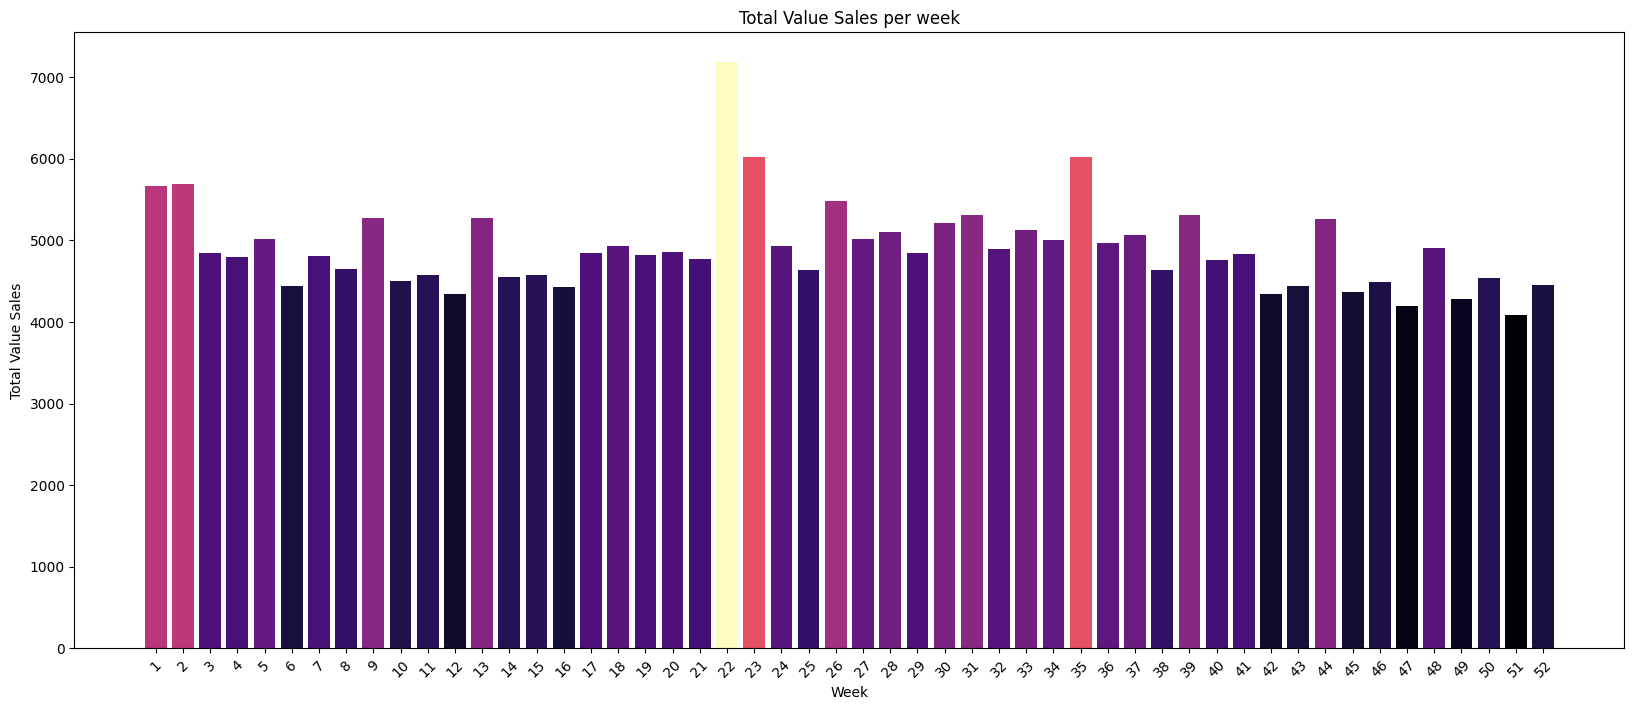

In [74]:
fig, ax = plt.subplots(figsize = (20,8))

# 1. Agrupar por semana y sumar las ventas (si quieres el total)
sales_2022_df_original = sales_product_2022_df_original.groupby('WEEK', as_index=False)['TOTAL_UNIT_SALES'].sum()

# Guardamos en una variable los valores que usaremos
valores_agg = sales_2022_df_original['TOTAL_UNIT_SALES']

# Normalizamos nuestros valores
norm = plt.Normalize(vmin = valores_agg.min(), vmax = valores_agg.max())

# Ahora obtén los colores aplicando la normalización y luego el mapa de colores
colores = plt.cm.magma(norm(valores_agg))

ax.bar(sales_2022_df_original['WEEK'] ,valores_agg, color = colores)

# Personalizar
ax.set_xticks(sales_2022_df_original['WEEK'])  # esto pondrá un tick en cada semana
ax.set_xticklabels(sales_2022_df_original['WEEK'], rotation=45)
ax.set_xlabel('Week')
ax.set_ylabel('Total Value Sales')
ax.set_title('Total Value Sales per week')
plt.savefig('barplot-total-value-sales-per-week-e-final.png') 

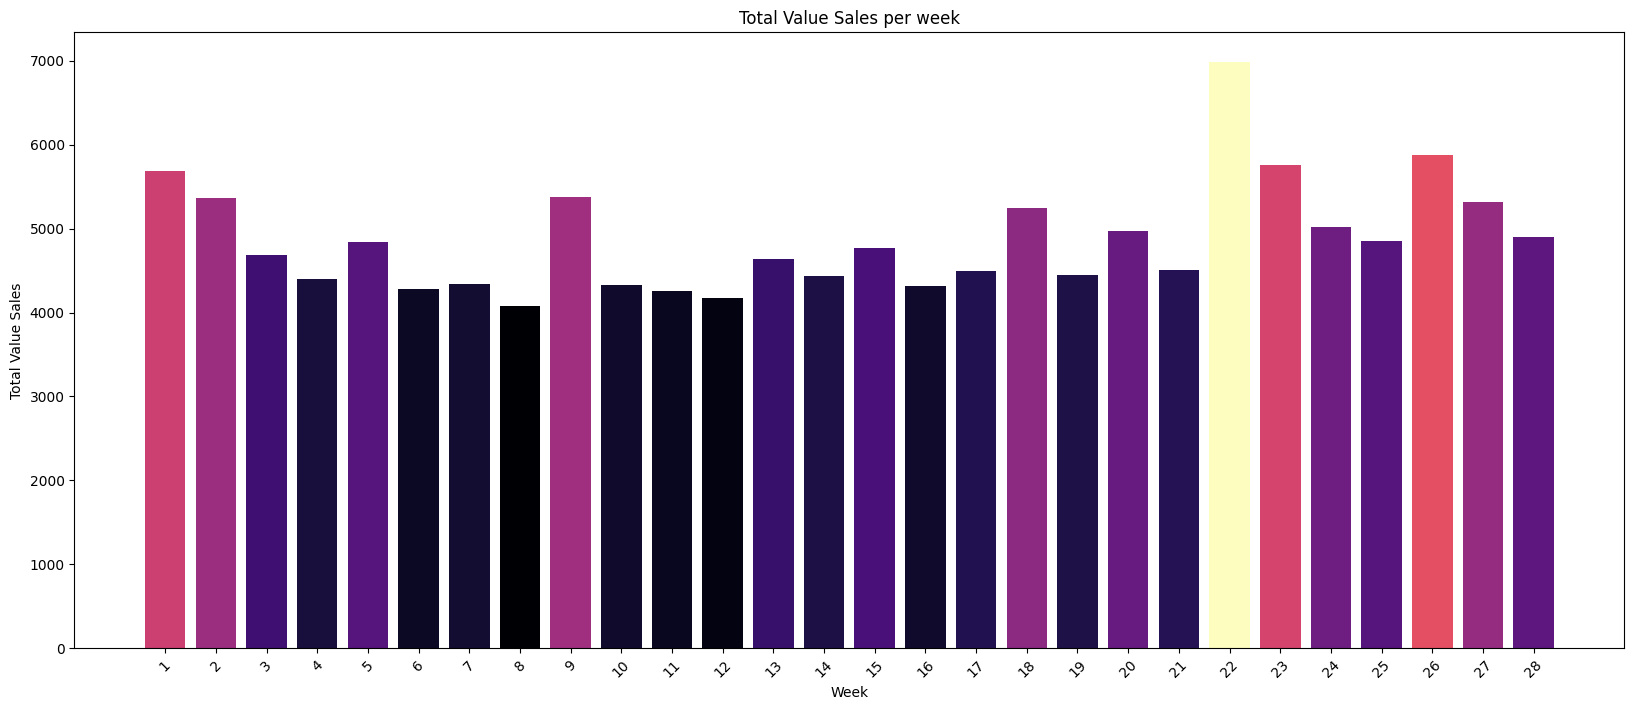

In [75]:
fig, ax = plt.subplots(figsize = (20,8))

# 1. Agrupar por semana y sumar las ventas (si quieres el total)
sales_2023_df_original = sales_product_2023_df_original.groupby('WEEK', as_index=False)['TOTAL_UNIT_SALES'].sum()

# Guardamos en una variable los valores que usaremos
valores_agg = sales_2023_df_original['TOTAL_UNIT_SALES']

# Normalizamos nuestros valores
norm = plt.Normalize(vmin = valores_agg.min(), vmax = valores_agg.max())

# Ahora obtén los colores aplicando la normalización y luego el mapa de colores
colores = plt.cm.magma(norm(valores_agg))

ax.bar(sales_2023_df_original['WEEK'] ,valores_agg, color = colores)

# Personalizar
ax.set_xticks(sales_2023_df_original['WEEK'])  # esto pondrá un tick en cada semana
ax.set_xticklabels(sales_2023_df_original['WEEK'], rotation=45)
ax.set_xlabel('Week')
ax.set_ylabel('Total Value Sales')
ax.set_title('Total Value Sales per week')
plt.savefig('barplot-total-value-sales-per-week-e-final.png') 

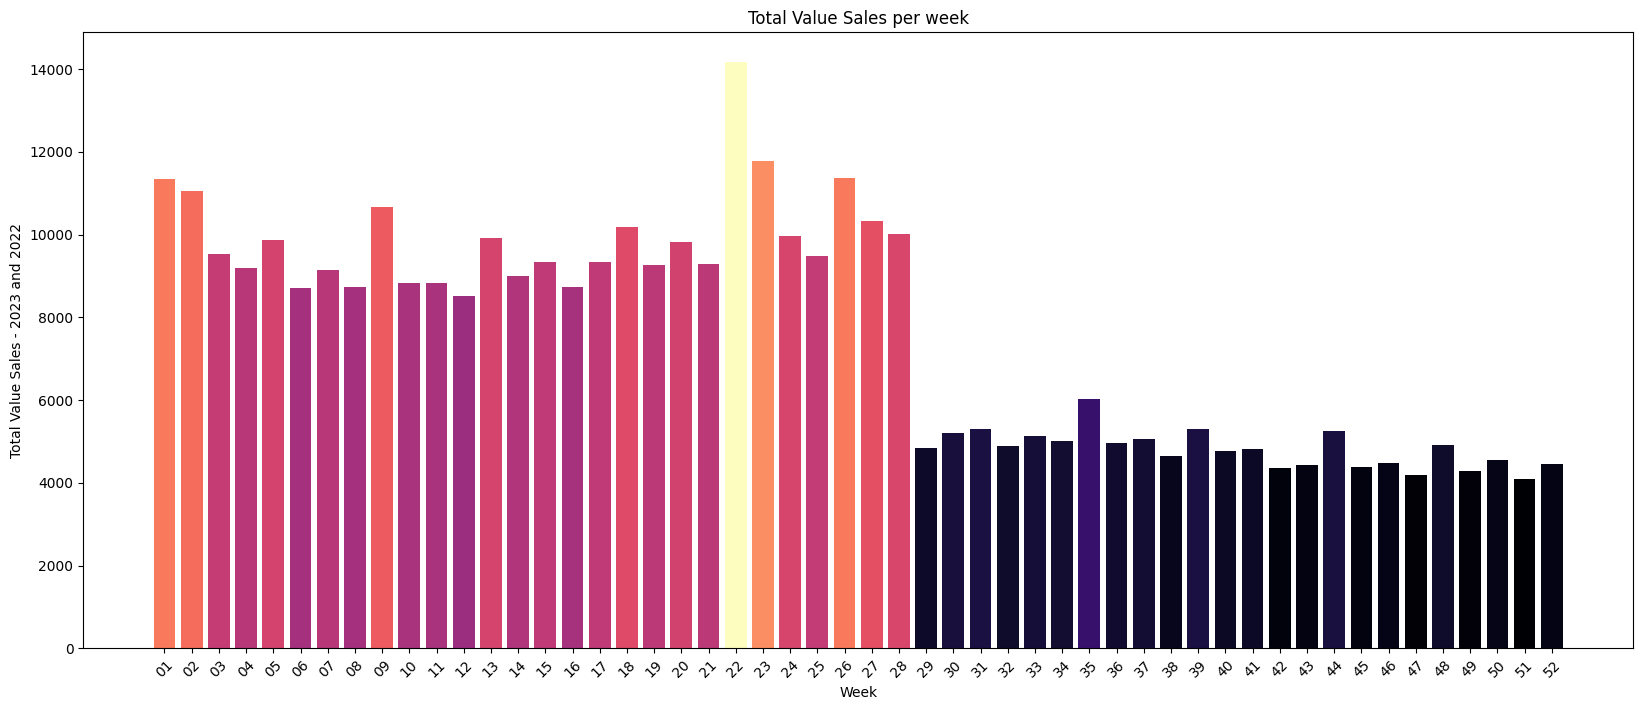

In [76]:
fig, ax = plt.subplots(figsize = (20,8))

# Agrupar por semana y sumar las ventas
total_sales_df_original = sales_product_df_original.groupby('WEEK', as_index=False)['TOTAL_UNIT_SALES'].sum()

# Guardamos en una variable los valores que usaremos
valores_agg = total_sales_df_original['TOTAL_UNIT_SALES']

# Normalizamos nuestros valores
norm = plt.Normalize(vmin = valores_agg.min(), vmax = valores_agg.max())

# Ahora obtén los colores aplicando la normalización y luego el mapa de colores
colores = plt.cm.magma(norm(valores_agg))

ax.bar(total_sales_df_original['WEEK'] ,total_sales_df_original['TOTAL_UNIT_SALES'], color = colores)

# Personalizar
plt.xticks(rotation = 45)
ax.set_xlabel('Week')
ax.set_ylabel('Total Value Sales - 2023 and 2022')
ax.set_title('Total Value Sales per week')
plt.savefig('barplot-total-value-sales-per-week-entrega-final.png') 
plt.show()


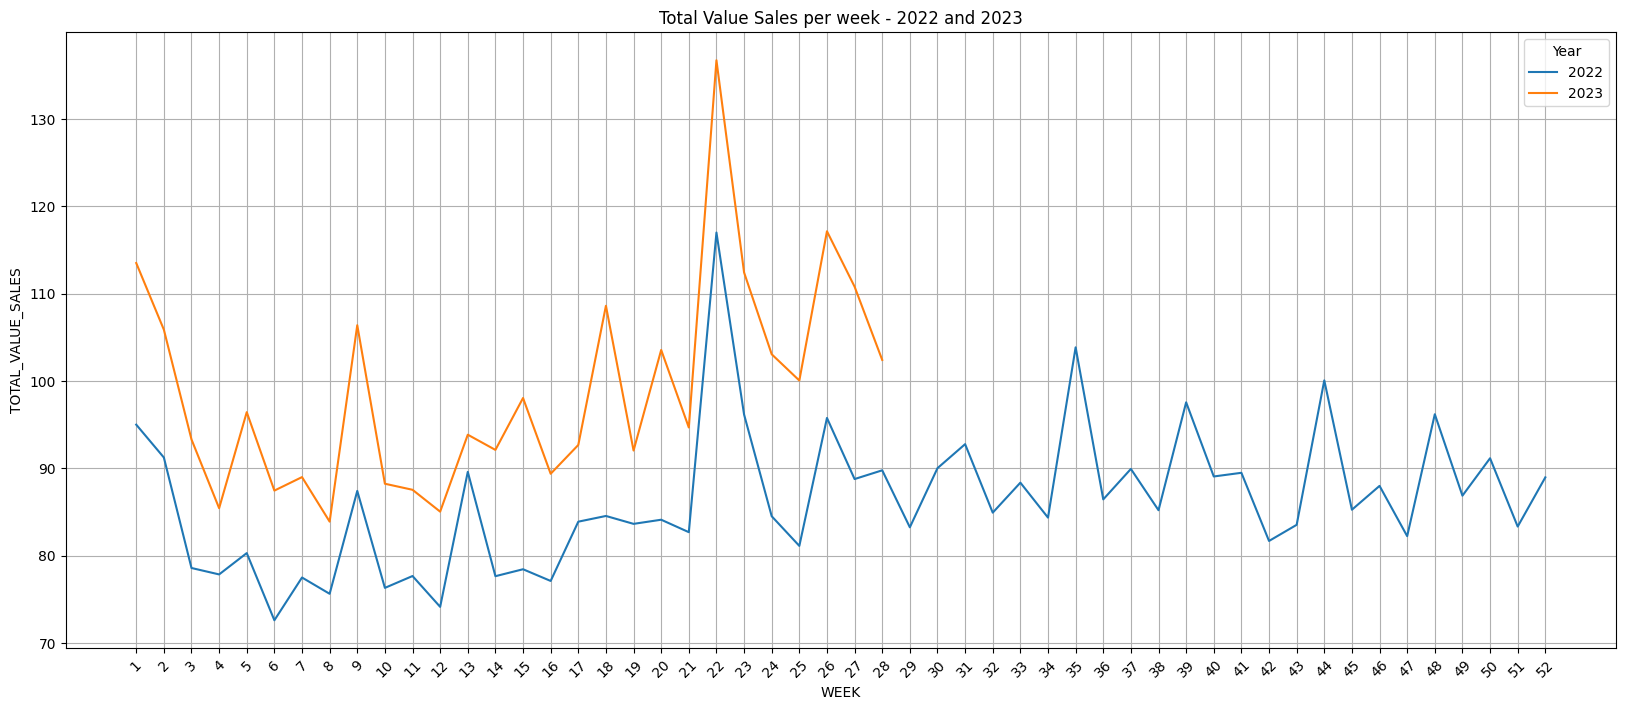

In [77]:
plt.figure(figsize = (20,8))

ax = sns.lineplot(data = sales_product_2022_df_original,
              x = 'WEEK', y = 'TOTAL_VALUE_SALES',
              ci = None, # Para que no muestre el intervalo de confianza
              label = '2022'
            ) 

ax = sns.lineplot(data = sales_product_2023_df_original,
             x = 'WEEK', y = 'TOTAL_VALUE_SALES',
             ci = None, # Para que no muestre el intervalo de confianza
             label = '2023'
            ) 

# Obtener todas las semanas únicas presentes en ambos años (ordenadas)
all_weeks = sorted(
    set(sales_product_2022_df_original['WEEK'].unique()) | 
    set(sales_product_2023_df_original['WEEK'].unique())
)


# Personalización

# Establecer los xticks para que aparezcan todas las semanas
ax.set_xticks(all_weeks)
ax.set_xticklabels(all_weeks, rotation = 45)
ax.set_title('Total Value Sales per week - 2022 and 2023')
ax.legend(title = 'Year')
plt.grid(True)

plt.savefig('lineplot-sns-total-value-sales-2022-and-2023-e-final.png')  
plt.show()

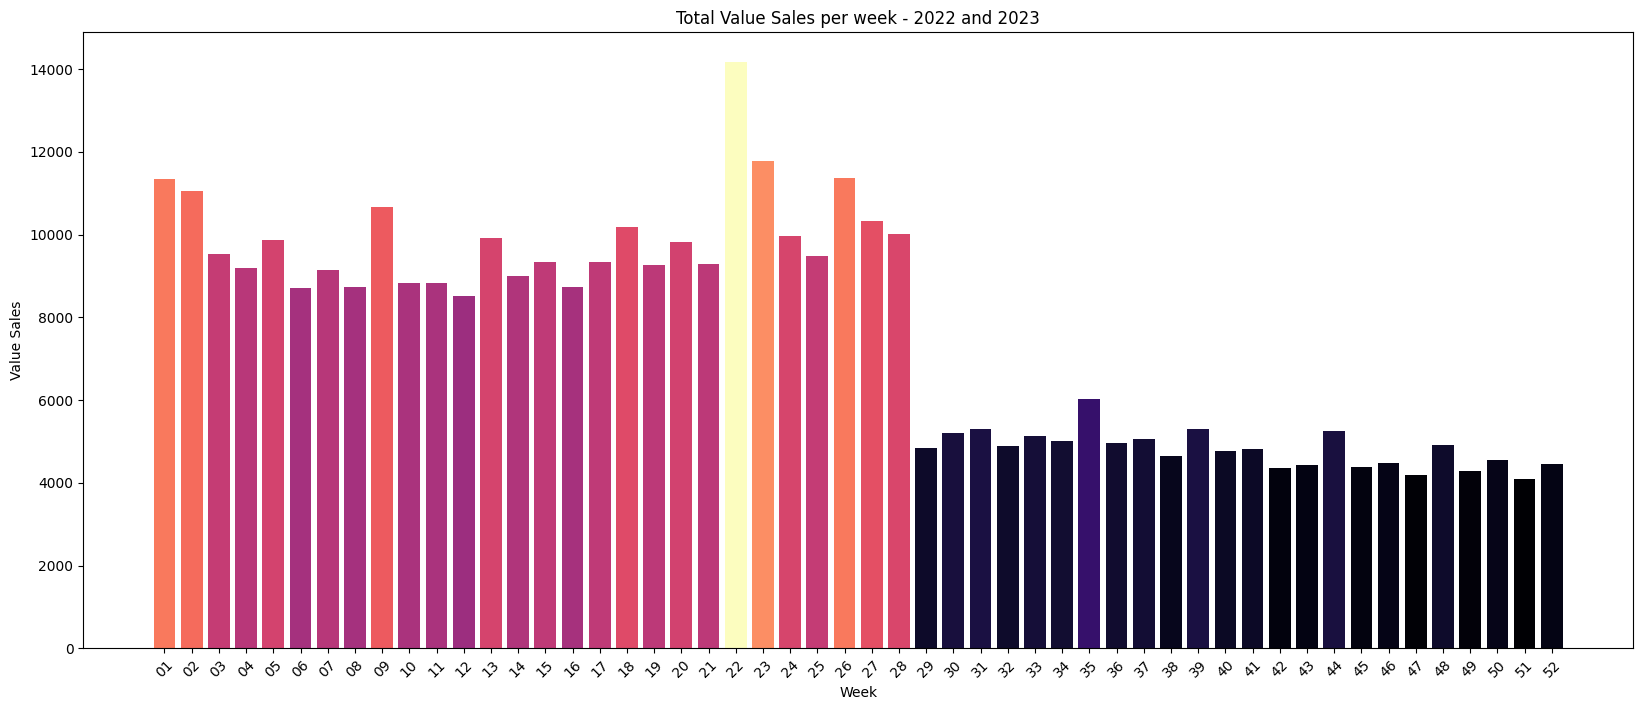

In [78]:
fig, ax = plt.subplots(figsize = (20,8))

# Agrupar por semana y sumar las ventas
total_sales_week_df = sales_product_df_original.groupby('WEEK', as_index=False)['TOTAL_UNIT_SALES'].sum()

# Guardamos en una variable los valores que usaremos
valores_agg = total_sales_week_df['TOTAL_UNIT_SALES']

# Normalizamos nuestros valores
norm = plt.Normalize(vmin = valores_agg.min(), vmax = valores_agg.max())

# Ahora obtén los colores aplicando la normalización y luego el mapa de colores
colores = plt.cm.magma(norm(valores_agg))

ax.bar(total_sales_week_df['WEEK'] ,valores_agg, color = colores)

# Personalizar
plt.xticks(rotation = 45)
ax.set_xlabel('Week')
ax.set_ylabel('Value Sales')
ax.set_title('Total Value Sales per week - 2022 and 2023')
# plt.grid(True)
plt.savefig('barplot-total-value-sales-per-week-2022-2023 e-final.png') 
plt.show()


# 4) Segmentación de Productos o Regiones con Clustering

In [79]:
sales_product_df_scaled.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,45,0000075000592,-0.219171,-0.258032,-0.070636,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-07,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,48,0000075000592,-0.221379,-0.258411,-0.401761,TOTAL AUTOS SCANNING MEXICO,2022,2022-11-28,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,03,0000075000592,-0.191715,-0.252852,0.189849,TOTAL AUTOS SCANNING MEXICO,2022,2022-01-17,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


### Vamos a segmentar por región 

In [80]:
sales_product_df_scaled['REGION'].unique()

array(['TOTAL AUTOS SCANNING MEXICO', 'TOTAL AUTOS AREA 1',
       'TOTAL AUTOS AREA 4', 'TOTAL AUTOS AREA 6', 'TOTAL AUTOS AREA 2',
       'TOTAL AUTOS AREA 5', 'TOTAL AUTOS AREA 3', nan], dtype=object)

In [81]:
# Hacemos una lista con columnas que vamos a utilizar para la segmentación
columnas_para_cluster = ['TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION']

In [82]:
# Verificamos que no tenga objetos nulos
print(sales_product_df_scaled.isnull().sum())

WEEK                           155
ITEM_CODE                        0
TOTAL_UNIT_SALES               155
TOTAL_VALUE_SALES              155
TOTAL_UNIT_AVG_WEEKLY_SALES    155
REGION                         155
YEAR                           155
WEEK_DATE                      155
MANUFACTURER                     0
BRAND                            0
ITEM_DESCRIPTION                 0
CATEGORY                         0
FORMAT                           0
ATTR1                            0
ATTR2                            0
ATTR3                            0
dtype: int64


In [83]:
# Si tiene, vamos a quitarlos 
sales_product_df_scaled.dropna(inplace = True) # La instrucción 'inplace' nos permite modificar el original sin tener que reasignar

In [84]:
# El cambio se hizo correctamente
print(sales_product_df_scaled.isnull().sum())

WEEK                           0
ITEM_CODE                      0
TOTAL_UNIT_SALES               0
TOTAL_VALUE_SALES              0
TOTAL_UNIT_AVG_WEEKLY_SALES    0
REGION                         0
YEAR                           0
WEEK_DATE                      0
MANUFACTURER                   0
BRAND                          0
ITEM_DESCRIPTION               0
CATEGORY                       0
FORMAT                         0
ATTR1                          0
ATTR2                          0
ATTR3                          0
dtype: int64


### Vamos a separar entre columnas númericas y categóricas

In [85]:
# Seleccionar numéricas de interés, de nuestro DataFrame creamos un DataFrame con solo estas 3 columnas
num_df = sales_product_df_scaled[['TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES']]

In [86]:
num_df.head(3)

,TOTAL_VALUE_SALES,TOTAL_UNIT_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
0,-0.258032,-0.219171,-0.070636
1,-0.258411,-0.221379,-0.401761
2,-0.252852,-0.191715,0.189849


In [87]:
# One-hot para REGION (igual que antes)
from sklearn.preprocessing import OneHotEncoder

# Crear dummies de la columna REGION con pandas
# Este codificador convierte nuestra variable categórica a una variable 'dummy' también llamadas variables indicadoras
region_dummies = pd.get_dummies(sales_product_df_scaled['REGION'], prefix='REGION')

In [88]:
# Concatenar todo en un DataFrame 
X = pd.concat([num_df, region_dummies], axis=1)

In [89]:
X.head(3)

,TOTAL_VALUE_SALES,TOTAL_UNIT_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION_TOTAL AUTOS AREA 1,REGION_TOTAL AUTOS AREA 2,REGION_TOTAL AUTOS AREA 3,REGION_TOTAL AUTOS AREA 4,REGION_TOTAL AUTOS AREA 5,REGION_TOTAL AUTOS AREA 6,REGION_TOTAL AUTOS SCANNING MEXICO
0,-0.258032,-0.219171,-0.070636,False,False,False,False,False,False,True
1,-0.258411,-0.221379,-0.401761,False,False,False,False,False,False,True
2,-0.252852,-0.191715,0.189849,False,False,False,False,False,False,True


In [90]:
# Importamos Kneans de nuestra librería de sklearn
from sklearn.cluster import KMeans

In [91]:
### Kmeans es un modelo que nos ayuda a serparar nuestros datos en grupos 'clusters'

In [92]:
wcss = []  # lista para almacenar las inercias (WCSS)

# Cada vez que se ejecuta el 'for' está entrenando nuestro modelo para cada k
for k in range(1, 11): # En un rando del 1 al 10 (no incluye el último valor)
    kmeans = KMeans(n_clusters = k, random_state=42, n_init=10) # k = número de clusters, random_state = semilla siempre tengas el mismo resultado
    kmeans.fit(X) # Ajusta nuestro modelo de Kmenas con nuestra información
    wcss.append(kmeans.inertia_) # La inercia del 'clustering' WCSS (Within-Cluster Sum of Squares)

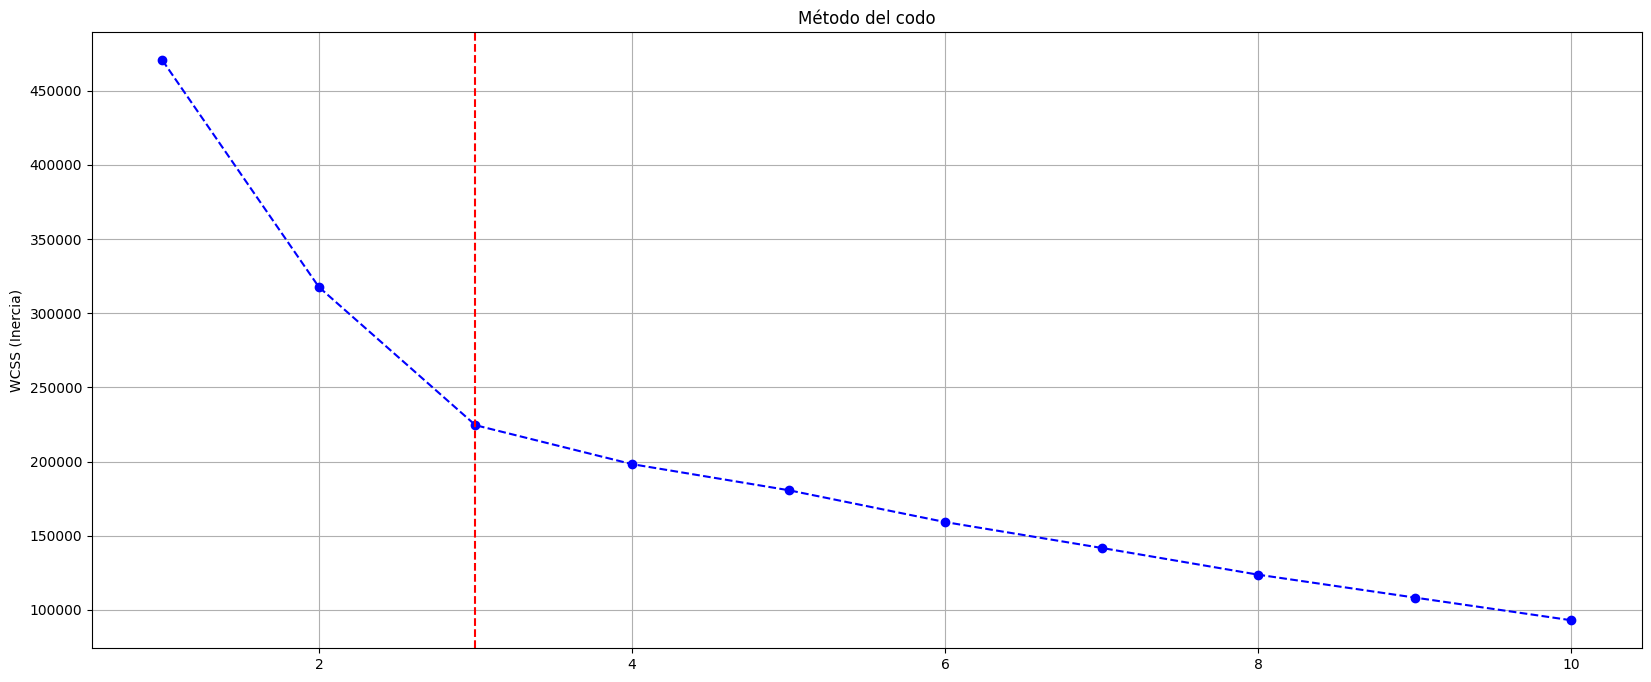

In [93]:
# Graficación del codo de Jambú, esto nos indica cual sería el número ideal de clusters

plt.figure(figsize = (20,8))

plt.plot(range(1, 11), wcss,  'o--',color = 'blue') # también puedes usar simplemente 'bo-'
plt.ylabel('WCSS (Inercia)')
plt.title('Método del codo')
plt.axvline(x = 3, linestyle='--', color='r')
plt.grid(True)
plt.savefig("Codo de Jambú.png")
plt.show() 

# podemos ser más explicitos usando linestyle = '-' o '--' o marker = 'o'
# El codo de Jambú nos indica que el valor óptimo de k (clusters) es de 3

In [94]:
k_optimo = 3 # Lo guardamos en una variable
kmeans_final = KMeans(n_clusters = k_optimo, random_state= 42, n_init= 10) # Nuestro kmeans con el numero óptímo el resultado lo guaramos en una variable
sales_product_df_scaled['cluster'] = kmeans_final.fit_predict(X) # Creamos nuestros clusters y los guardamos en una columna 'cluster'

In [95]:
type(sales_product_df_scaled['cluster']) # El modelo nos devuelve una serie de pandas

pandas.core.series.Series

In [96]:
# Verificar distribución, con está instrucción podemos ver nuesta distibución (nuestros 'clusters')
print(sales_product_df_scaled['cluster'] .value_counts())

cluster
0    118176
1      3566
2       260
Name: count, dtype: int64


In [97]:
# Crear fields con las dos columnas que quieres visualizar
fields = X[['TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES']].values # Estamos visualizando la posición 0 y 2

In [98]:
fields # Es un arreglor de dos dimensiones

array([[-0.25803173, -0.07063578],
       [-0.25841148, -0.40176089],
       [-0.25285235,  0.1898493 ],
       ...,
       [-0.25646136, -0.38851588],
       [-0.25638141, -0.39809644],
       [-0.25638141, -0.39809644]], shape=(122002, 2))

In [99]:
# Obtener las etiquetas de cluster como un array (cluster_values)
cluster_values = sales_product_df_scaled['cluster'].values

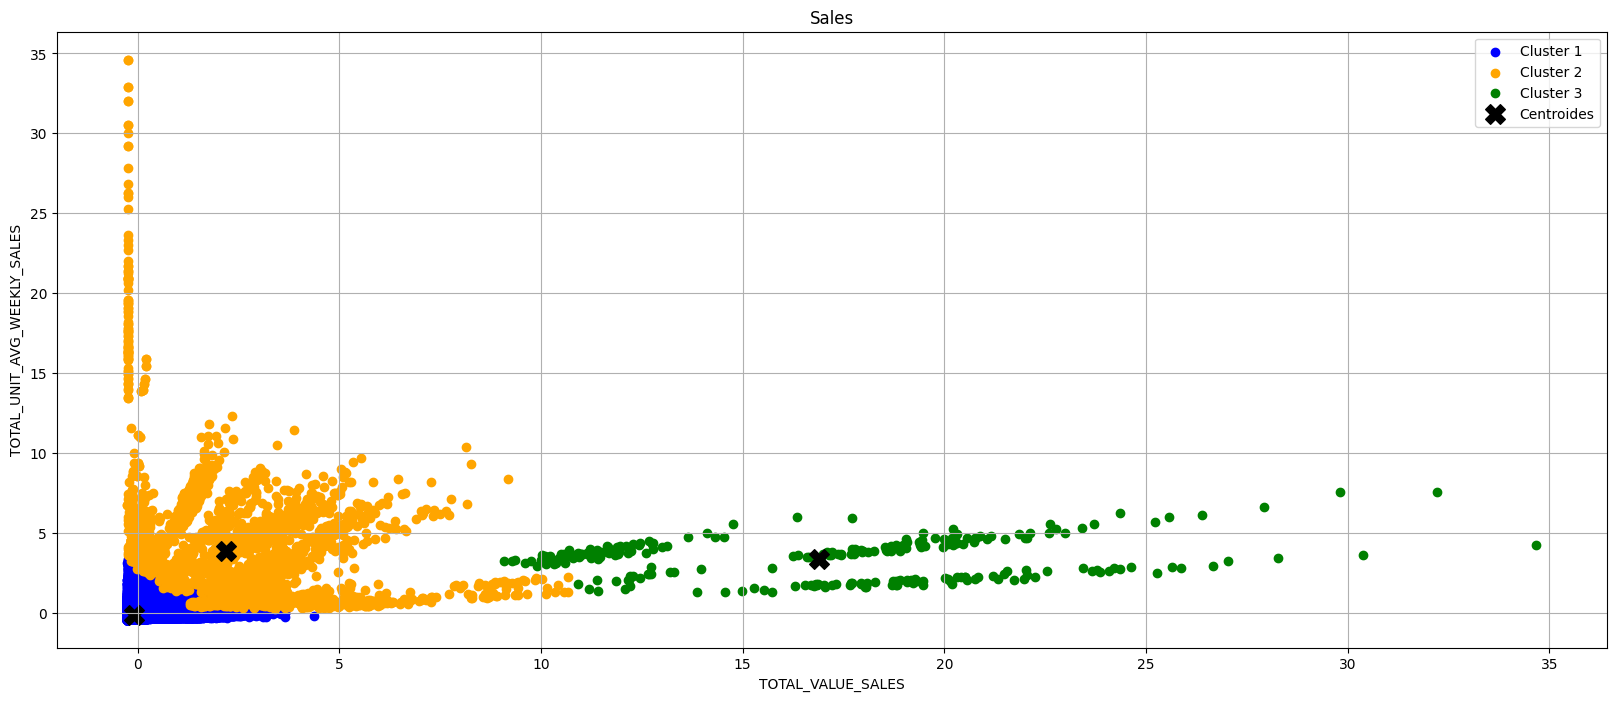

In [100]:
# Hacemos nuestro gráfico de la segmentación 
plt.figure(figsize=(20,8))

# cluster_values produce una máscara booleana esto es:, si el cluster es 0 toma solo la columna 0(x), si el cluster es 0 toma la columna 1(y)
plt.scatter(fields[cluster_values== 0,0], fields[cluster_values==0,1], c="blue", label="Cluster 1")

# cluster_values produce una máscara booleana esto es:, si el cluster es 1 toma solo la columna 0 (x), si el cluster es 1 toma la columna 1(y)
plt.scatter(fields[cluster_values== 1,0], fields[cluster_values==1,1], c="orange", label="Cluster 2")

# cluster_values produce una máscara booleana esto es:, si el cluster es 2 toma solo la columna 0(x), si el cluster es 1 toma la columna 1(y)
plt.scatter(fields[cluster_values==2,0], fields[cluster_values==2,1], c="green", label="Cluster 3")
# (solo 3 clusters en tu caso)

# Con esto gráficamos nuestros centroídes el punto 'medio' de nuestros clusters
# x = kmeans_final.cluster_centers_[:,0] Todas las filas de la posición 0 
# y = kmeans_final.cluster_centers_[:,0] Todas las filas de la posición 2 

plt.scatter(kmeans_final.cluster_centers_[:,0], kmeans_final.cluster_centers_[:,2], c="black", marker='X', s=200, label="Centroides")
plt.title("Sales")
plt.xlabel("TOTAL_VALUE_SALES")
plt.ylabel("TOTAL_UNIT_AVG_WEEKLY_SALES")
plt.legend()
plt.grid(True)

plt.savefig("Segmentación-Clusters.png")
plt.show()

# Puntos 5 y 6 están en el arcchivo .pptx

# 7) Regresión lineal

In [101]:
sales_regression_df = sales_df_original.copy()

In [102]:
sales_regression_df.head(3)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE
0,34,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022,2022-08-22
1,34,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,2022,2022-08-22
2,34,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,2022,2022-08-22


In [103]:
# Vamos a separar variable independiente 'X' y variable independiendte 'y'
feature_cols = ['TOTAL_UNIT_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES']

In [104]:
# 'X' es nuestra variable independiente
X = sales_regression_df[feature_cols]

In [105]:
X.head(3)

,TOTAL_UNIT_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
0,0.006,1.000
1,0.487,2.916
2,1.391,5.171


In [106]:
# y es nuestra variable dependiente, la que más adelante vamos a predecir
y = sales_regression_df['TOTAL_VALUE_SALES']

In [107]:
# Dividir entrenamiento y prueba

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # Haremos nuestro test con el 20 % de nuestros datos

In [108]:
# Ajustar modelo 

# Importamos LinearRefresion
from sklearn.linear_model import LinearRegression 

model_linearR = LinearRegression() # Lo guaraamos en una variable
model_linearR.fit(X_train, y_train) # Hacemos el ajuste con nuestros datos


# Coeficientes
print("Intercepto:", model_linearR.intercept_)
print("Coeficientes:", dict(zip(X.columns, model_linearR.coef_)))

Intercepto: 22.293695283660696
Coeficientes: {'TOTAL_UNIT_SALES': np.float64(22.65044258036689), 'TOTAL_UNIT_AVG_WEEKLY_SALES': np.float64(-0.4324213109713738)}


In [109]:
model_linearR

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Evaluar el modelo 

In [110]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model_linearR.predict(X_test)  # Predicción de variable dependiente sobre nuestro grupo 'test'
print("R² en test: ", r2_score(y_test, y_pred)) # La R² Nos indica la presición de nuestro modelo 

# Root Mean Square Error (Raíz del Error Cuadrático Medio 
# Es una de las métricas más utilizadas para evaluar la precisión de modelos de regresión 
# El RMSE te dice, en promedio, qué tan lejos están las predicciones de la realidad, pero dándole más peso a los errores grandes.
print("RMSE: ", np.sqrt(mean_squared_error(y_test,y_pred))) 

R² en test:  0.8311003567494627
RMSE:  144.45959052817346


### Análisis estadístico detallado

In [111]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
modelo_sm = sm.OLS(y_train, X_train_sm).fit() # Agregamos una constante por si modelo pasa por el 0,0
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:      TOTAL_VALUE_SALES   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                 2.607e+05
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:59:47   Log-Likelihood:            -6.2006e+05
No. Observations:               97601   AIC:                         1.240e+06
Df Residuals:                   97598   BIC:                         1.240e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

### Modelo ARIMA Y series de tiempo

In [112]:
# Visualizamos nuestro DataFrame
sales_df_original.head() 

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,WEEK_DATE
0,34,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022,2022-08-22
1,34,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,2022,2022-08-22
2,34,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,2022,2022-08-22
3,34,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,2022,2022-08-22
4,34,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,2022,2022-08-22


In [113]:
value_sales_original_df = sales_df_original.copy()

In [114]:
value_sales_original_sum_df  = value_sales_original_df.groupby('WEEK_DATE')['TOTAL_VALUE_SALES'].sum()

In [115]:
value_sales_original_sum_df.head()

WEEK_DATE
2022-01-03    151538.922
2022-01-10    146996.991
2022-01-17    125351.336
2022-01-24    123945.617
2022-01-31    129841.767
Name: TOTAL_VALUE_SALES, dtype: float64

In [116]:
value_sales_original_sum_df = value_sales_original_sum_df.to_frame()

In [117]:
value_sales_original_sum_df

,TOTAL_VALUE_SALES
WEEK_DATE,
2022-01-03,151538.922
2022-01-10,146996.991
2022-01-17,125351.336
2022-01-24,123945.617
2022-01-31,129841.767
...,...
2023-06-12,149143.134
2023-06-19,143092.153
2023-06-26,168005.338


In [118]:
sales_ts_suma_df = value_sales_original_sum_df.copy()

In [119]:
sales_ts_suma_df

,TOTAL_VALUE_SALES
WEEK_DATE,
2022-01-03,151538.922
2022-01-10,146996.991
2022-01-17,125351.336
2022-01-24,123945.617
2022-01-31,129841.767
...,...
2023-06-12,149143.134
2023-06-19,143092.153
2023-06-26,168005.338


In [120]:
# Utilizaremos el 80% de nuestros datos para nuestro 'grupo' train
len_train= int(len(sales_ts_suma_df) * 0.8) 
print(len_train)

64


In [121]:
# Utilizaremos el 20% de nuestros datos para nuestro 'grupo' test
len_test = int(len(sales_ts_suma_df) * 0.2)
print(len_test)

16


In [122]:
# Definición de grupos de prueba y entrenamiento
train = sales_ts_suma_df[0:len_train]
train

,TOTAL_VALUE_SALES
WEEK_DATE,
2022-01-03,151538.922
2022-01-10,146996.991
2022-01-17,125351.336
2022-01-24,123945.617
2022-01-31,129841.767
...,...
2023-02-20,123082.737
2023-02-27,158318.691
2023-03-06,130157.160


In [123]:
test = sales_ts_suma_df[len_train:]
test

,TOTAL_VALUE_SALES
WEEK_DATE,
2023-03-27,137876.647
2023-04-03,135044.755
2023-04-10,143264.959
2023-04-17,130143.276
2023-04-24,134853.380
2023-05-01,156961.164
2023-05-08,132911.862
2023-05-15,149961.002
2023-05-22,137195.883


### Autocorrelación

[ 1.          0.13153246 -0.02381869 -0.13399702  0.32317022  0.06136793
 -0.10748328 -0.11702049  0.04847139  0.25267841 -0.23528883 -0.15104116
 -0.17873975  0.30989617 -0.12855196 -0.11954024 -0.25730327  0.087229
  0.044589  ]


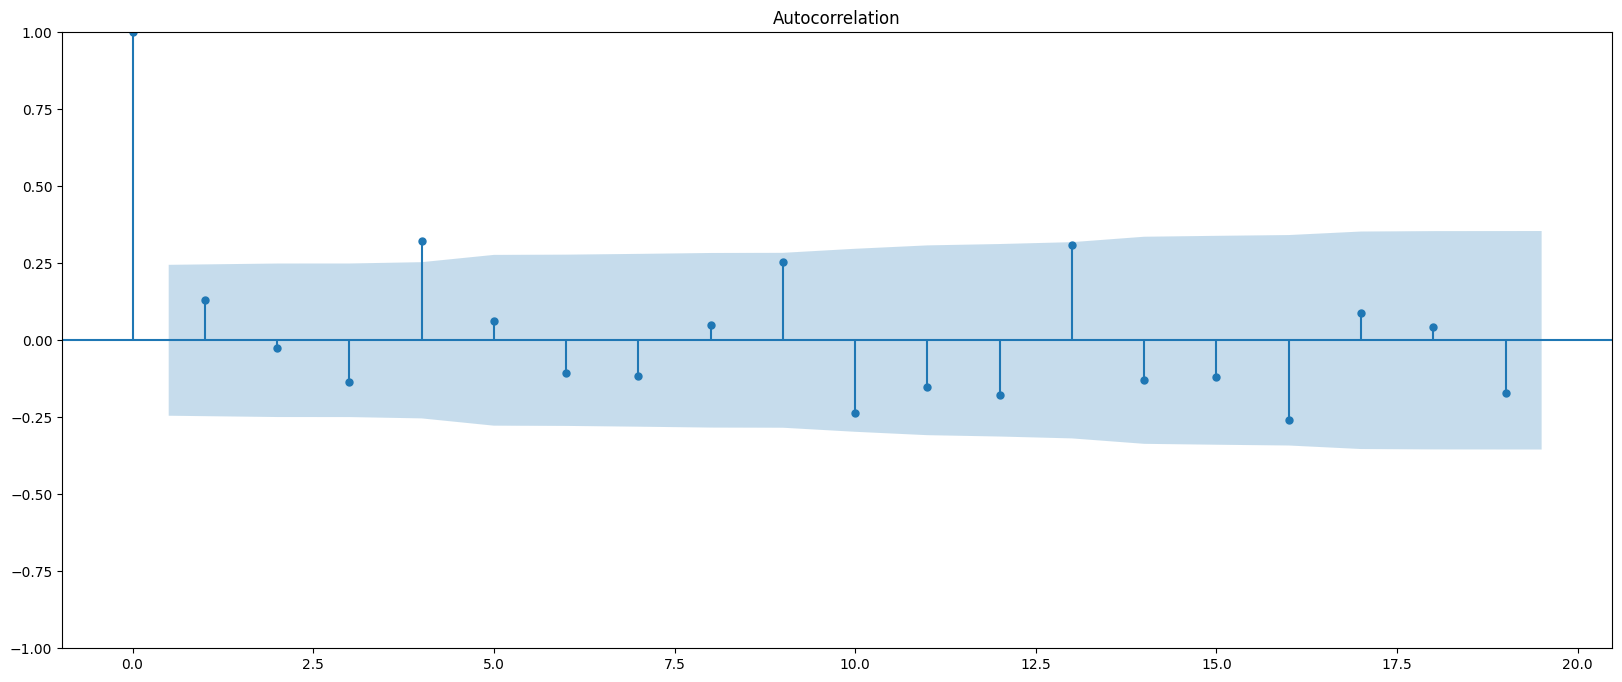

In [124]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf # 'time series analysis'
from statsmodels.graphics.tsaplots import plot_acf # Auto-correlation function

acf_array = acf(train)
print(acf_array)

# Gráficos con un nivel de confianza del 95% 
fig, ax = plt.subplots(figsize=(20,8))
plot_acf(train, alpha = 0.05, ax=ax)

plt.savefig("Autocorrelación.png")
plt.show()

# Como se correlacionan con su anterior

In [125]:
### Salvo el primer valor todos los demás valos se encuentran en el intervalor de confianza esto es que los valores no son significativamente diferebtes a 0
### Excepto el primer valor, la correlación es baja

[ 1.          0.13362027 -0.04321295 -0.13402434  0.39555612 -0.07055336
 -0.16109388  0.05446317 -0.07179875  0.29940656 -0.43376228  0.03035505
 -0.13667132  0.27477971 -0.22555161 -0.05949927 -0.19984655 -0.04834194
  0.15647555]


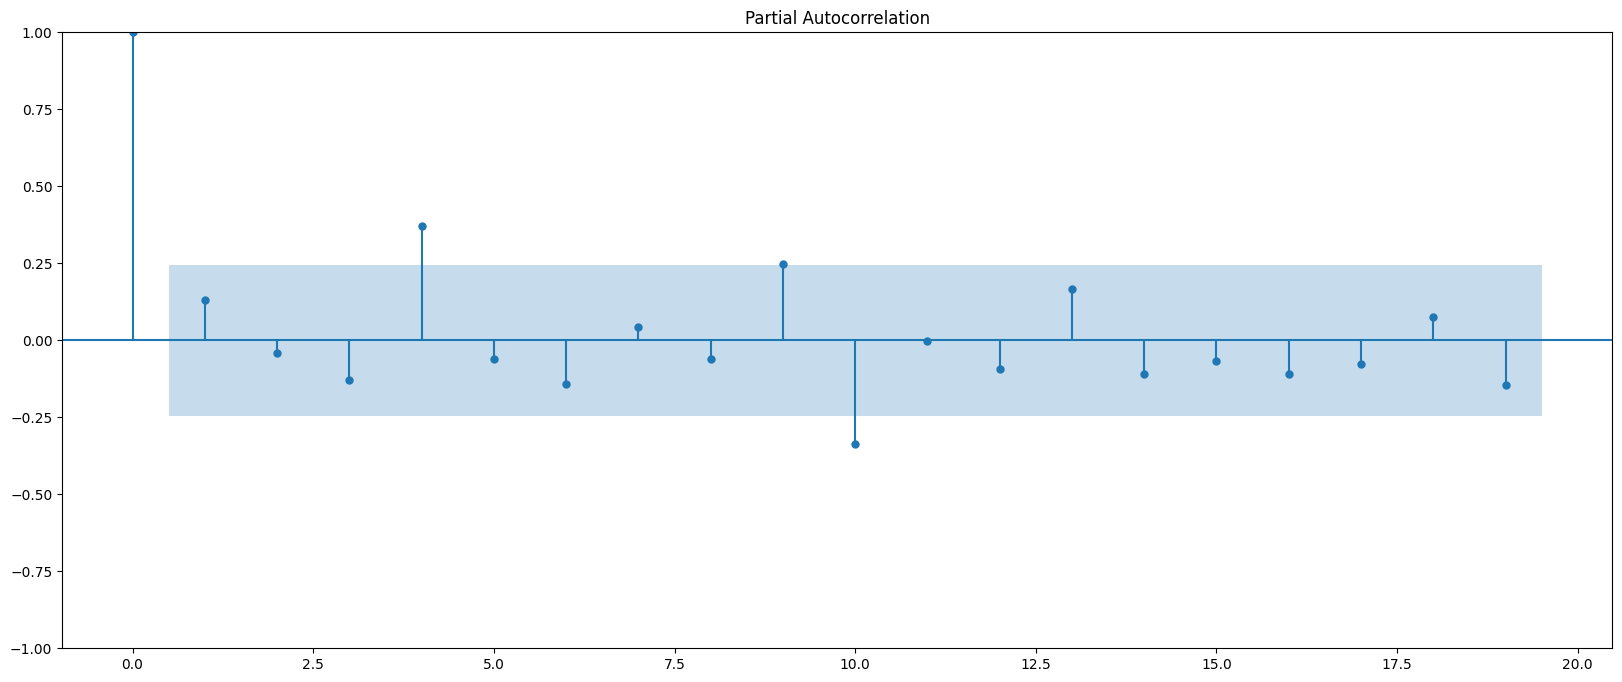

In [126]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf # 'time series analysis'
from statsmodels.graphics.tsaplots import plot_pacf # Auto-correlation parcial

pacf_array = pacf(train)
print(pacf_array)

# Gráficos con un nivel de confianza del 95% 
fig, ax = plt.subplots(figsize=(20,8))
plot_pacf(train, alpha = 0.05, ax=ax)

plt.savefig("Autocorrelación parcial.png")
plt.show()

# Como se correlacionan con su anterior

In [127]:
print(train.isnull().sum())

TOTAL_VALUE_SALES    0
dtype: int64


In [128]:
### Salvo el primer valor todos los demás valos se encuentran en el intervalor de confianza esto es que los valores no son significativamente diferebtes a 0
### Excepto el primer valor, la correlación parcial es baja

### Prueba de Dickey-fuller

In [129]:
from statsmodels.tsa.stattools import adfuller
result_fuller = adfuller(sales_ts_suma_df['TOTAL_VALUE_SALES'])
print('El valor p de la prueba de Dickey-Fuller es: ', result_fuller[1])

El valor p de la prueba de Dickey-Fuller es:  0.7625145328394436


### Conclusión: No hay evidencia estadística para rechazar H0 (y por lo tanto decir que la serie es estacionaria)

In [130]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Supongamos que 'train' es tu serie de entrenamiento
max_diff = 5  # Límite de seguridad (normalmente 2 es suficiente)
d = 0
serie_actual = train.copy()  # Trabajamos con una copia para no modificar el original

while d < max_diff:
    # Realizar prueba de Dickey-Fuller en la serie actual
    resultado = adfuller(serie_actual.dropna())  # .dropna() por si hay NaN por diferencias
    p_valor = resultado[1]
    print(f'd = {d}, p-valor = {p_valor:.6f}')
    
    if p_valor < 0.05:
        print(f'La serie es estacionaria con d = {d}')
        break
    else:
        # Aplicar una diferencia más
        serie_actual = serie_actual.diff().dropna()
        d += 1

if d == max_diff and p_valor >= 0.05:
    print(f'No se alcanzó estacionariedad después de {max_diff} diferencias.')
else:
    print(f'Se recomienda d = {d} para el modelo ARIMA.')
    serie_estacionaria = serie_actual  # Esta es la serie con d diferencias

d = 0, p-valor = 0.079597
d = 1, p-valor = 0.021603
La serie es estacionaria con d = 1
Se recomienda d = 1 para el modelo ARIMA.


In [131]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")  # para evitar mensajes molestos

resultados = []

# Definir rangos a probar (ajusta según lo que viste en los gráficos)
for p in range(0, 4):      # p = 0,1,2,3
    for q in range(0, 4):  # q = 0,1,2,3
        try:
            modelo = ARIMA(train, order=(p, d, q)).fit()
            resultados.append((p, d, q, modelo.aic))
            print(f'ARIMA({p},{d},{q}) - AIC: {modelo.aic:.2f}')  # Criterio de Información de Akaike (AIC)
        except: 
            # Algunas combinaciones pueden no converger
            print(f'ARIMA({p},{d},{q}) - ERROR')
            continue

# Seleccionar el modelo con menor AIC
mejor = min(resultados, key=lambda x: x[3])
print(f'\nMejor modelo: ARIMA{mejor[:3]} con AIC = {mejor[3]:.2f}')

ARIMA(0,1,0) - AIC: 1406.54
ARIMA(0,1,1) - AIC: 1398.63
ARIMA(0,1,2) - AIC: 1395.16
ARIMA(0,1,3) - AIC: 1396.30
ARIMA(1,1,0) - AIC: 1402.84
ARIMA(1,1,1) - AIC: 1396.34
ARIMA(1,1,2) - AIC: 1396.98
ARIMA(1,1,3) - AIC: 1394.75
ARIMA(2,1,0) - AIC: 1401.24
ARIMA(2,1,1) - AIC: 1400.69
ARIMA(2,1,2) - AIC: 1397.90
ARIMA(2,1,3) - AIC: 1395.28
ARIMA(3,1,0) - AIC: 1396.10
ARIMA(3,1,1) - AIC: 1397.60
ARIMA(3,1,2) - AIC: 1399.56
ARIMA(3,1,3) - AIC: 1396.92

Mejor modelo: ARIMA(1, 1, 3) con AIC = 1394.75


### Podemos ver conforme avanza el tiempo hay mayor correlación entre un dato y otro

In [132]:
from statsmodels.tsa.arima.model import ARIMA

# Fit an ARIMA(1,1,3) model to the training data
mod_arima = ARIMA(train, order = (1,1,3)) 
res = mod_arima.fit()
print(res.summary())
print("\n")
print("El AIC para AR(1,1,3) es: ", res.aic)

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   64
Model:                 ARIMA(1, 1, 3)   Log Likelihood                -692.377
Date:                Fri, 20 Mar 2026   AIC                           1394.755
Time:                        23:59:50   BIC                           1405.470
Sample:                    01-03-2022   HQIC                          1398.969
                         - 03-20-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6640      0.350     -1.895      0.058      -1.351       0.023
ma.L1          0.3110      0.352      0.884      0.377      -0.378       1.000
ma.L2         -0.4464      0.230     -1.941      0.0

### Según el 'AIC' (Criterio de Información de Akaike el modelo ARIMA(1, 1, 3) es el que mejor equilibra ajuste y conpejidad

In [133]:
# Predicciones
fcast_object = res.forecast(len(test) + 5) ## Proonóstico de los 5 períodos posteriores al último dato (test)

In [134]:
fcast_object

2023-03-27    133607.193189
2023-04-03    130384.968397
2023-04-10    133383.089457
2023-04-17    131392.283617
2023-04-24    132714.214191
2023-05-01    131836.428720
2023-05-08    132419.293923
2023-05-15    132032.261036
2023-05-22    132289.257774
2023-05-29    132118.607358
2023-06-05    132231.922277
2023-06-12    132156.679150
2023-06-19    132206.641928
2023-06-26    132173.465753
2023-07-03    132195.495324
2023-07-10    132180.867296
2023-07-17    132190.580568
2023-07-24    132184.130782
2023-07-31    132188.413555
2023-08-07    132185.569717
2023-08-14    132187.458076
Freq: W-MON, Name: predicted_mean, dtype: float64

In [135]:
fcast_object = fcast_object.to_frame() # Con esta instrucción cambiamos una seri a Dataframe

In [136]:
fcast_object

,predicted_mean
2023-03-27,133607.193189
2023-04-03,130384.968397
2023-04-10,133383.089457
2023-04-17,131392.283617
2023-04-24,132714.214191
2023-05-01,131836.428720
2023-05-08,132419.293923
2023-05-15,132032.261036
2023-05-22,132289.257774
2023-05-29,132118.607358


In [137]:
# Intervalos de confianza
conf = res.get_forecast(len(test)).conf_int(alpha = 0.05) # Intervalo de confianza de un 95%
conf

,lower TOTAL_VALUE_SALES,upper TOTAL_VALUE_SALES
2023-03-27,105732.449668,161481.936709
2023-04-03,97185.326363,163584.610431
2023-04-10,98038.274155,168727.904759
2023-04-17,95218.939642,167565.627593
2023-04-24,95009.021990,170419.406391
2023-05-01,93143.765805,170529.091636
2023-05-08,92459.742868,172378.844978
2023-05-15,91044.908095,173019.613977
2023-05-22,90171.379309,174407.136239
2023-05-29,88983.311856,175253.902859


In [138]:
fcast_object_res = res.get_forecast(len(test)) # Con esto obtenemos el resúmen de nuestro modelo ARIMA
print(fcast_object_res.summary_frame(alpha = 0.05))

TOTAL_VALUE_SALES           mean       mean_se  mean_ci_lower  mean_ci_upper
2023-03-27         133607.193189  14222.069253  105732.449668  161481.936709
2023-04-03         130384.968397  16938.904131   97185.326363  163584.610431
2023-04-10         133383.089457  18033.400400   98038.274155  168727.904759
2023-04-17         131392.283617  18456.126878   95218.939642  167565.627593
2023-04-24         132714.214191  19237.696457   95009.021990  170419.406391
2023-05-01         131836.428720  19741.517304   93143.765805  170529.091636
2023-05-08         132419.293923  20387.900681   92459.742868  172378.844978
2023-05-15         132032.261036  20912.299034   91044.908095  173019.613977
2023-05-22         132289.257774  21489.108370   90171.379309  174407.136239
2023-05-29         132118.607358  22008.208233   88983.311856  175253.902859
2023-06-05         132231.922277  22542.834537   88048.778475  176415.066078
2023-06-12         132156.679150  23047.154581   86985.086225  177328.272075

In [139]:
test = test.reset_index() # Reset al index esto porqué no queremos porqué usaremos un index nuevo para nuestra serie de tiempo
test.head() 

,WEEK_DATE,TOTAL_VALUE_SALES
0,2023-03-27,137876.647
1,2023-04-03,135044.755
2,2023-04-10,143264.959
3,2023-04-17,130143.276
4,2023-04-24,134853.380


In [140]:
# Visualizamos nuestro test
test

,WEEK_DATE,TOTAL_VALUE_SALES
0,2023-03-27,137876.647
1,2023-04-03,135044.755
2,2023-04-10,143264.959
3,2023-04-17,130143.276
4,2023-04-24,134853.380
5,2023-05-01,156961.164
6,2023-05-08,132911.862
7,2023-05-15,149961.002
8,2023-05-22,137195.883
9,2023-05-29,199783.534


In [141]:
test = test.set_index('WEEK_DATE')

In [142]:
test.head(3)

,TOTAL_VALUE_SALES
WEEK_DATE,
2023-03-27,137876.647
2023-04-03,135044.755
2023-04-10,143264.959


In [143]:
# Visulizamos nuestro fcast_object
fcast_object.head()

,predicted_mean
2023-03-27,133607.193189
2023-04-03,130384.968397
2023-04-10,133383.089457
2023-04-17,131392.283617
2023-04-24,132714.214191


In [144]:
fcast_object.reset_index(inplace=True)

In [145]:
fcast_object.head(3)

,index,predicted_mean
0,2023-03-27,133607.193189
1,2023-04-03,130384.968397
2,2023-04-10,133383.089457


In [146]:
fcast_object = fcast_object.rename(columns = {"index":"WEEK_DATE"})

In [147]:
test.head(3)

,TOTAL_VALUE_SALES
WEEK_DATE,
2023-03-27,137876.647
2023-04-03,135044.755
2023-04-10,143264.959


In [148]:
fcast_object.head(3)

,WEEK_DATE,predicted_mean
0,2023-03-27,133607.193189
1,2023-04-03,130384.968397
2,2023-04-10,133383.089457


In [149]:
test.head()

,TOTAL_VALUE_SALES
WEEK_DATE,
2023-03-27,137876.647
2023-04-03,135044.755
2023-04-10,143264.959
2023-04-17,130143.276
2023-04-24,134853.380


In [150]:
# Hacemos un 'reset' del 'index' para tener 2 columnas
test.reset_index(inplace=True)

In [151]:
test

,WEEK_DATE,TOTAL_VALUE_SALES
0,2023-03-27,137876.647
1,2023-04-03,135044.755
2,2023-04-10,143264.959
3,2023-04-17,130143.276
4,2023-04-24,134853.380
5,2023-05-01,156961.164
6,2023-05-08,132911.862
7,2023-05-15,149961.002
8,2023-05-22,137195.883
9,2023-05-29,199783.534


In [152]:
import numpy as np 

acumulador1 = 0
acumulador2 = 0


for contador in range(1,16):
    if test.iloc[contador][1] != 0:
        acumulador2 += np.abs((test.iloc[contador][1] - fcast_object.iloc[contador][1]) / test.iloc[contador][1])
    
    acumulador1 = acumulador1 + (test.iloc[contador][1] - fcast_object.iloc[contador][1]) ** 2

mse = acumulador1 / 16  # Promedio de los errores al cuadrado
rsme = np.round(np.sqrt(mse), 2) # MSE (Mean Squared Error):
mape = np.round((acumulador2 / 16) * 100, 2)# MAPE (Mean Absolute Percentage Error)

print("RMSE = ", rsme, 'MAPE = ', mape, '%')

RMSE =  23931.54 MAPE =  10.24 %


### Calculamos el MAE (Mean absolut error)

In [153]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE: {mae:.2f}')

MAE: 45.30


In [154]:
sales_ts_suma_df

,TOTAL_VALUE_SALES
WEEK_DATE,
2022-01-03,151538.922
2022-01-10,146996.991
2022-01-17,125351.336
2022-01-24,123945.617
2022-01-31,129841.767
...,...
2023-06-12,149143.134
2023-06-19,143092.153
2023-06-26,168005.338


In [155]:
# Hacemos un reset del index
sales_ts_suma_df = sales_ts_suma_df.reset_index()

In [156]:
fcast_object

,WEEK_DATE,predicted_mean
0,2023-03-27,133607.193189
1,2023-04-03,130384.968397
2,2023-04-10,133383.089457
3,2023-04-17,131392.283617
4,2023-04-24,132714.214191
5,2023-05-01,131836.428720
6,2023-05-08,132419.293923
7,2023-05-15,132032.261036
8,2023-05-22,132289.257774
9,2023-05-29,132118.607358


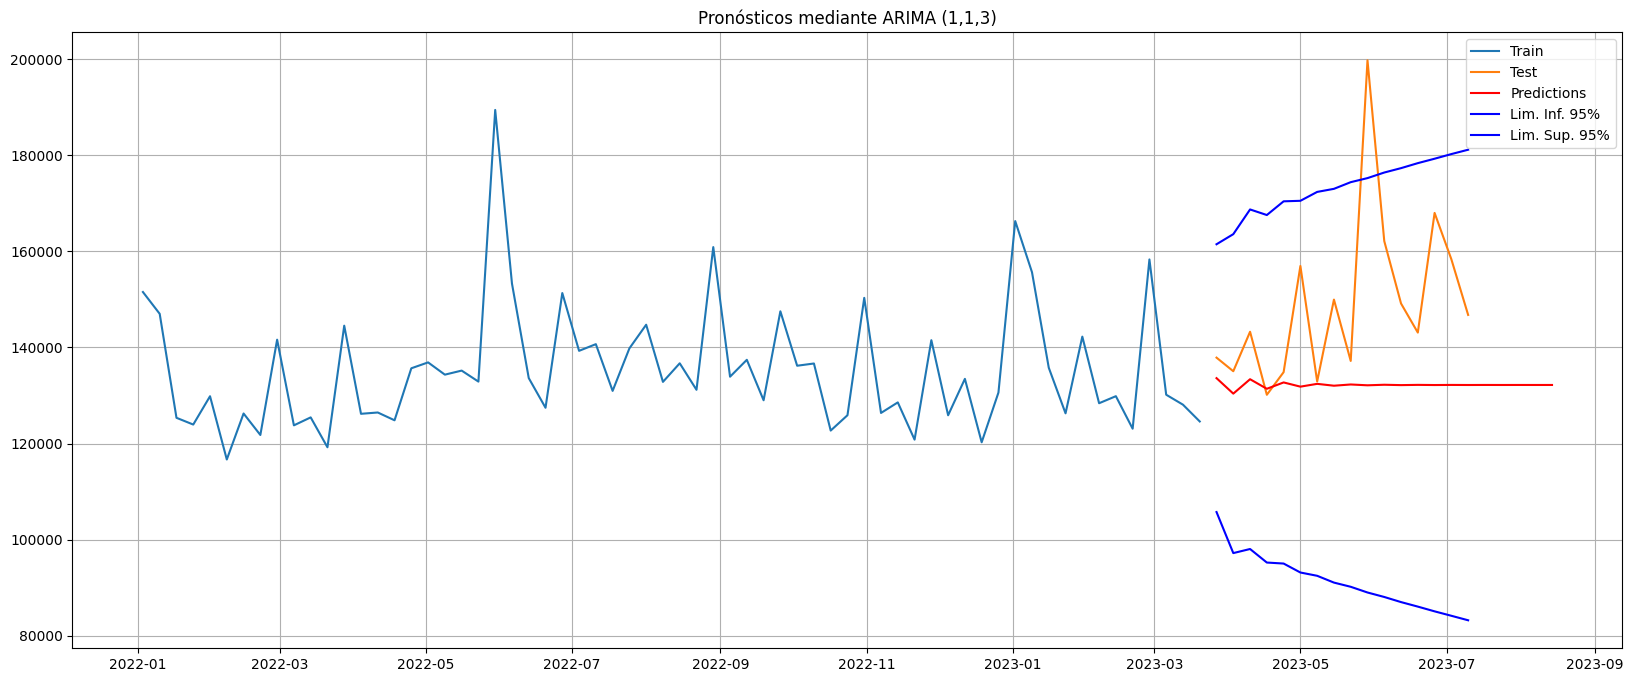

In [157]:
plt.figure(figsize = (20,8))

plt.plot(train.index, train.values, label='Train')
plt.plot(test['WEEK_DATE'], test['TOTAL_VALUE_SALES'],  label = 'Test')
plt.plot(fcast_object['WEEK_DATE'], fcast_object['predicted_mean'], label='Predictions', color='red')
plt.plot(conf.index, conf['lower TOTAL_VALUE_SALES'], label='Lim. Inf. 95%', color='blue')
plt.plot(conf.index, conf['upper TOTAL_VALUE_SALES'], label='Lim. Sup. 95%', color='blue')
plt.legend(loc = 'best')
plt.title('Pronósticos mediante ARIMA (1,1,3)')
plt.grid(True)

plt.savefig('pronostico.png')
plt.show()